In [113]:
# ============================================
# SAVE ALL NOTEBOOK OUTPUTS TO TEXT FILE
# ============================================

import sys
import os

# Create output directory
os.makedirs('/kaggle/working/logs', exist_ok=True)

# Log file path
log_path = '/kaggle/working/logs/notebook_output.txt'


# ============================================
# CUSTOM LOGGER CLASS
# ============================================

class Logger(object):

    def __init__(self, filename):

        self.terminal = sys.stdout
        self.log = open(filename, "w")

    def write(self, message):

        self.terminal.write(message)
        self.log.write(message)

    def flush(self):
        pass


# ============================================
# REDIRECT OUTPUT
# ============================================

sys.stdout = Logger(log_path)

print("Notebook output logging started successfully.")
print(f"Saving outputs to:\n{log_path}")

In [114]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, haere's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session


# IMPORT LIBRARIES

In [115]:


import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')


# ============================================
# DISPLAY SETTINGS
# ============================================

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


# ============================================
# RANDOM SEED FOR REPRODUCIBILITY
# ============================================

RANDOM_STATE = 42

print("Environment setup complete.")


# INSPECT KAGGLE INPUT DIRECTORY



In [116]:

import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    
    print(f"\nFOLDER: {dirname}")
    
    for filename in filenames:
        print("   ", filename)

# 1. Load Main Dataset

Load the Epileptic Seizure Recognition dataset, which will be used as the primary dataset for preprocessing, regularization, and imbalance handling experiments.

In [117]:
# Load dataset

dataset_path = "/kaggle/input/datasets/harunshimanto/epileptic-seizure-recognition/Epileptic Seizure Recognition.csv"

df = pd.read_csv(dataset_path)

print("Dataset loaded successfully.")

# 2. Dataset Inspection

Inspect the dataset structure, feature information, missing values, and class distribution before preprocessing and modeling.

In [118]:
# ============================================
# DATASET INSPECTION FUNCTION
# ============================================

def inspect_dataset(df):
    
    print("=" * 60)
    print("DATASET OVERVIEW")
    print("=" * 60)

    # Shape
    print(f"\nShape: {df.shape}")

    # Columns
    print("\nColumns:")
    print(df.columns.tolist())

    # Data types
    print("\nData Types:")
    print(df.dtypes)

    # Missing values
    print("\nMissing Values:")
    print(df.isnull().sum())

    # Duplicate rows
    print(f"\nDuplicate Rows: {df.duplicated().sum()}")

    # Memory usage
    memory = df.memory_usage(deep=True).sum() / 1024**2
    print(f"\nMemory Usage: {memory:.2f} MB")

    # First rows
    print("\nFirst 5 Rows:")
    display(df.head())

    print("=" * 60)


# Run inspection
inspect_dataset(df)

,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,X24,X25,X26,X27,X28,X29,X30,X31,X32,X33,X34,X35,X36,X37,X38,X39,X40,X41,X42,X43,X44,X45,X46,X47,X48,X49,X50,X51,X52,X53,X54,X55,X56,X57,X58,X59,X60,X61,X62,X63,X64,X65,X66,X67,X68,X69,X70,X71,X72,X73,X74,X75,X76,X77,X78,X79,X80,X81,X82,X83,X84,X85,X86,X87,X88,X89,X90,X91,X92,X93,X94,X95,X96,X97,X98,X99,X100,X101,X102,X103,X104,X105,X106,X107,X108,X109,X110,X111,X112,X113,X114,X115,X116,X117,X118,X119,X120,X121,X122,X123,X124,X125,X126,X127,X128,X129,X130,X131,X132,X133,X134,X135,X136,X137,X138,X139,X140,X141,X142,X143,X144,X145,X146,X147,X148,X149,X150,X151,X152,X153,X154,X155,X156,X157,X158,X159,X160,X161,X162,X163,X164,X165,X166,X167,X168,X169,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,-38,-10,35,64,113,152,164,127,50,-47,-121,-138,-125,-101,-50,11,39,24,48,64,46,13,-19,-61,-96,-130,-132,-116,-115,-71,-14,25,19,6,9,21,13,-37,-58,-33,5,47,80,101,88,73,69,41,-13,-31,-61,-80,-77,-66,-43,5,87,129,121,88,12,-76,-150,-207,-186,-165,-148,-103,-33,40,94,75,8,-81,-155,-227,-262,-233,-218,-187,-126,-65,-12,27,61,49,9,-46,-124,-210,-281,-265,-181,-89,-4,53,53,38,43,31,34,9,-7,-34,-70,-84,-101,-70,-11,42,62,66,74,64,59,56,36,-11,-30,-43,-23,8,42,77,103,135,121,79,59,43,54,90,111,107,64,32,18,-25,-69,-65,-44,-33,-57,-88,-114,-130,-114,-83,-53,-79,-72,-85,-109,-98,-72,-65,-63,-11,10,8,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,232,237,258,212,2,-267,-605,-850,-1001,-1109,-1090,-967,-746,-464,-152,118,318,427,473,485,447,397,339,312,314,326,335,332,324,310,312,309,309,303,297,295,295,293,286,279,283,301,308,285,252,215,194,169,111,-74,-388,-679,-892,-949,-972,-1001,-1006,-949,-847,-668,-432,-153,72,226,326,392,461,495,513,511,496,479,453,440,427,414,399,385,385,404,432,444,437,418,392,373,363,365,372,385,388,383,371,360,353,334,303,252,200,153,151,143,48,-206,-548,-859,-1067,-1069,-957,-780,-597,-460,-357,-276,-224,-210,-350,-930,-1413,-1716,-1360,-662,-96,243,323,241,29,-167,-228,-136,27,146,229,269,297,307,303,305,306,307,280,231,159,85,51,43,62,63,63,69,89,123,136,127,102,95,105,131,163,168,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,-94,-99,-94,-96,-104,-103,-92,-75,-69,-69,-53,-37,-14,-10,-39,-78,-102,-98,-80,-54,-40,-35,-39,-32,-13,7,34,41,33,6,-15,-30,-47,-53,-65,-64,-68,-85,-98,-109,-82,-57,-38,-40,-36,-31,-13,11,19,9,-20,-48,-71,-71,-57,-32,-13,6,29,27,25,10,-7,-36,-47,-37,-36,-22,-32,-38,-55,-61,-64,-72,-67,-53,-25,-10,-4,-23,-55,-93,-102,-106,-101,-69,-45,-42,-57,-64,-77,-80,-77,-78,-56,-34,-5,10,5,-5,-44,-75,-99,-110,-104,-103,-94,-105,-108,-110,-99,-89,-82,-76,-80,-90,-106,-106,-108,-87,-60,-37,-26,-15,-6,-14,-23,-34,-41,-54,-82,-107,-126,-124,-108,-84,-68,-61,-56,-63,-62,-33,1,28,45,37,48,62,80,66,23,-11,-39,-44,-42,-45,-48,-42,-6,29,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,-79,-72,-68,-74,-80,-83,-73,-68,-61,-58,-59,-64,-79,-84,-97,-94,-84,-77,-75,-72,-68,-76,-76,-72,-67,-69,-69,-69,-67,-68,-69,-67,-66,-58,-54,-56,-70,-80,-82,-85,-74,-70,-71,-82,-88,-93,-97,-89,-87,-83,-70,-50,-37,-31,-32,-39,-54,-64,-68,-67,-69,-63,-60,-63,-55,-43,-37,-27,-31,-35,-47,-58,-63,-74,-73,-67,-60,-56,-49,-46,-57,-58,-62,-63,-63,-61,-56,-65,-62,-57,-61,-63,-66,-69,-86,-89,-86,-83,-87,-80,-69,-62,-57,-60,-60,-68,-58,-53,-57,-66,-66,-73,-78,-73,-84,-92,-97,-88,-81,-72,-61,-66,-72,-88,-90,-88,-77,-58,-53,-61,-69,-66,-74,-69,-61,-51,-45,-45,-49,-58,-64,-78,-80,-90,-87,-83,-78,-64,-38,-22,-29,-42,-51,-68,-71,-69,-69,-74,-74,-80,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,-59,-90,-103,-84,-43,-9,3,-21,-60,-96,-103,-75,-29,14,55,78,73,28,-13,-43,-68,-78,-75,-55,-41,-19,-20,-29,-36,-20,1,16,14,-14,-42,-56,-45,-45,-45,-38,-47,-45,-37,-3,23,39,27,0,-28,-44,-37,-22,5,30,31,6,-32,-27,-27,2,13,-6,-29,-41,-22,-13,-16,-31,-52,-60,-40,-16,0,14,24,36,39,3

# 3. Initial Data Cleaning

Remove unnecessary columns and convert the target labels into binary classes for seizure vs non-seizure classification.

In [119]:
# ============================================
# REMOVE UNNECESSARY COLUMN
# ============================================

df.drop(columns=['Unnamed'], inplace=True)


# ============================================
# CONVERT TARGET INTO BINARY CLASSES
# ============================================

# Original:
# 1 = seizure
# 2,3,4,5 = non-seizure

df['y'] = df['y'].apply(lambda x: 1 if x == 1 else 0)


# ============================================
# VERIFY CHANGES
# ============================================

print("Updated Shape:", df.shape)

print("\nTarget Class Distribution:")
print(df['y'].value_counts())

# 4. Class Distribution Analysis

Visualize the distribution of seizure and non-seizure samples to examine class imbalance in the dataset.

In [120]:
# ============================================
# CREATE FIGURE DIRECTORY
# ============================================

import os

os.makedirs('/kaggle/working/figures', exist_ok=True)

print("Figure directory created.")

# 4. Class Distribution Analysis

Visualize the distribution of seizure and non-seizure samples to analyze class imbalance in the dataset.

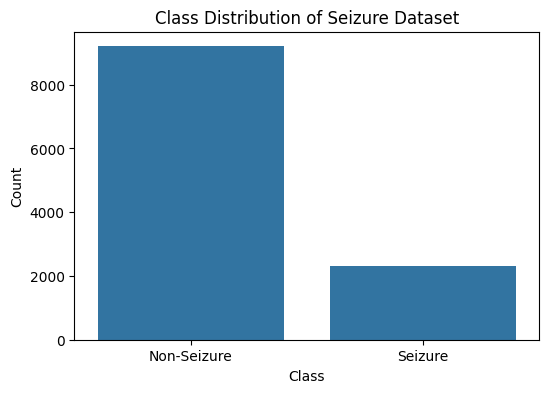

In [121]:
# ============================================
# CLASS DISTRIBUTION VISUALIZATION
# ============================================

plt.figure(figsize=(6,4))

sns.countplot(x='y', data=df)

plt.title("Class Distribution of Seizure Dataset")
plt.xlabel("Class")
plt.ylabel("Count")

plt.xticks(
    ticks=[0,1],
    labels=['Non-Seizure', 'Seizure']
)

# Save figure
plt.savefig(
    '/kaggle/working/figures/class_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Figure saved successfully.")

# 5. Correlation Analysis

Analyze feature correlations to understand feature relationships and support later preprocessing and regularization experiments.

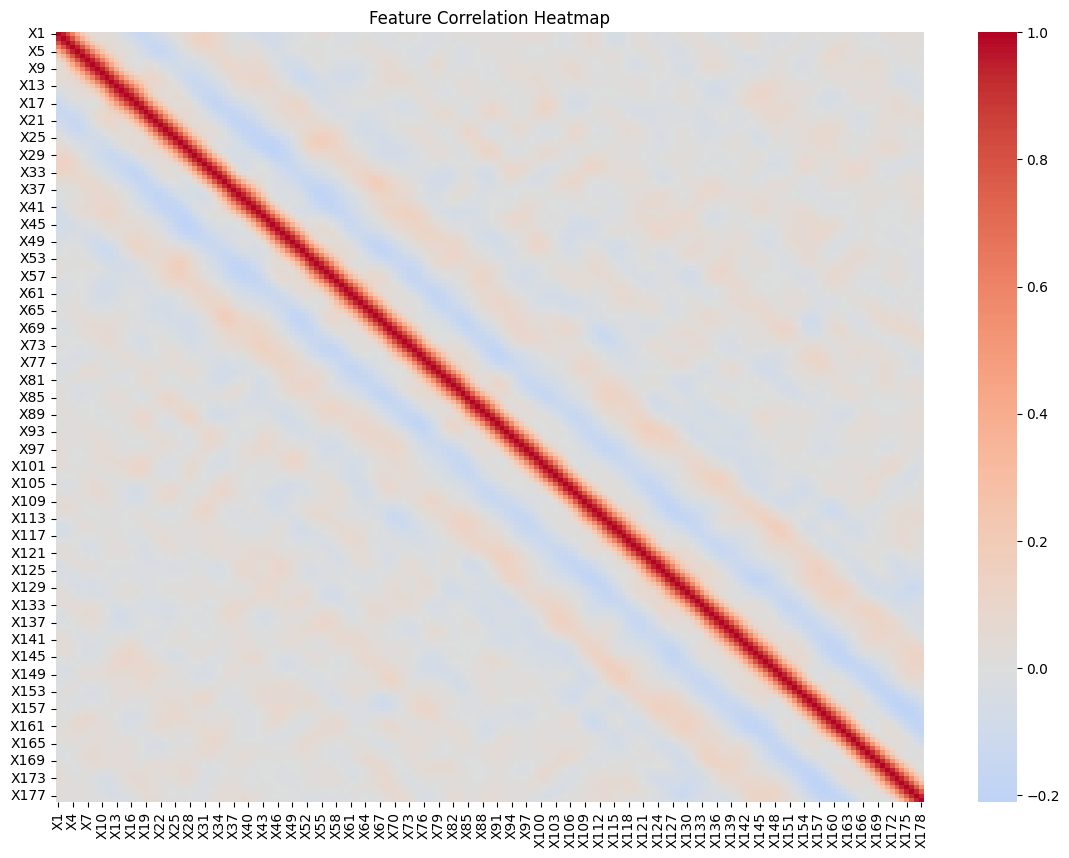

In [122]:
# ============================================
# CORRELATION HEATMAP
# ============================================

# Compute correlation matrix
correlation_matrix = df.drop('y', axis=1).corr()

# Plot heatmap
plt.figure(figsize=(14,10))

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    center=0
)

plt.title("Feature Correlation Heatmap")

# Save figure
plt.savefig(
    '/kaggle/working/figures/correlation_heatmap.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Figure saved successfully.")

# 6. Feature Distribution Analysis

Visualize sample feature distributions to examine feature ranges and support scaling decisions for preprocessing pipelines.

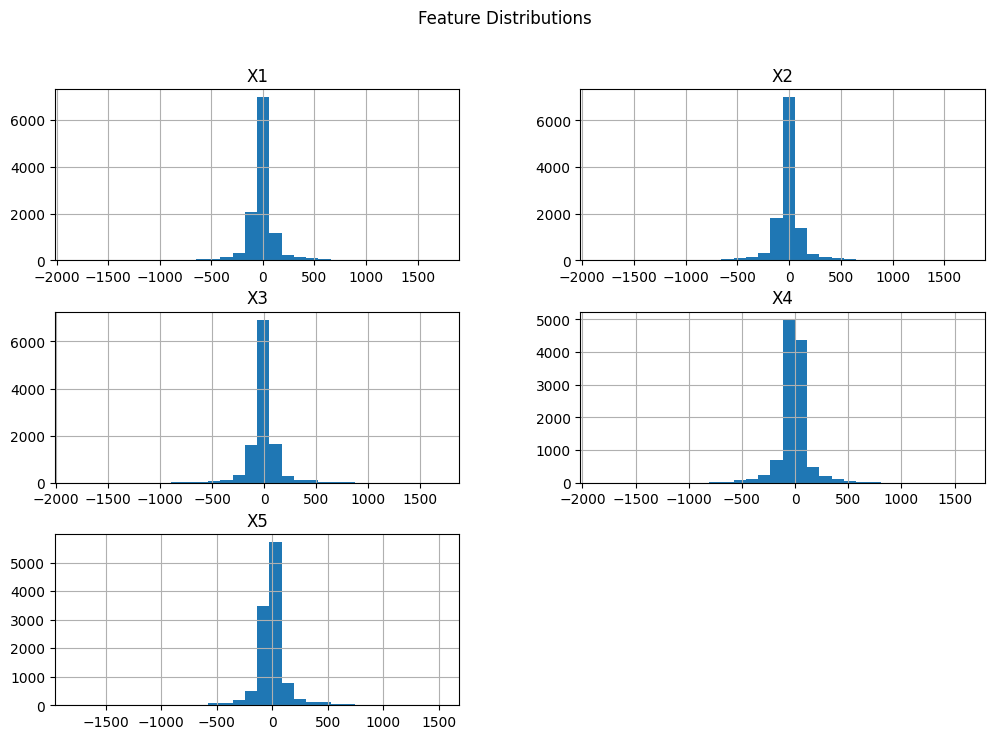

In [123]:
# ============================================
# FEATURE DISTRIBUTION VISUALIZATION
# ============================================

# Select a few sample features
sample_features = ['X1', 'X2', 'X3', 'X4', 'X5']

# Plot distributions
df[sample_features].hist(
    figsize=(12,8),
    bins=30
)

plt.suptitle("Feature Distributions")

# Save figure
plt.savefig(
    '/kaggle/working/figures/feature_distributions.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Figure saved successfully.")

# 7. Train-Test Split

Split the dataset into training and testing sets while preserving class distribution using stratified sampling.

In [124]:
# ============================================
# SEPARATE FEATURES AND TARGET
# ============================================

X = df.drop('y', axis=1)
y = df['y']


# ============================================
# TRAIN-TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)


# ============================================
# VERIFY SPLIT
# ============================================

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

print("\nTraining Class Distribution:")
print(y_train.value_counts())

print("\nTesting Class Distribution:")
print(y_test.value_counts())

# 8. Feature Scaling

Apply standardization to normalize feature scales before Logistic Regression modeling.

In [125]:
# ============================================
# STANDARD SCALING
# ============================================

from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data
X_test_scaled = scaler.transform(X_test)


# ============================================
# VERIFY SCALING
# ============================================

print("Scaled Training Shape:", X_train_scaled.shape)
print("Scaled Testing Shape:", X_test_scaled.shape)

print("\nFeature Mean After Scaling (approx):")
print(np.mean(X_train_scaled[:, 0]))

print("\nFeature Std After Scaling (approx):")
print(np.std(X_train_scaled[:, 0]))

# 9. Baseline Logistic Regression

Train a baseline Logistic Regression model using standardized EEG features.

In [126]:
# ============================================
# BASELINE LOGISTIC REGRESSION
# ============================================

from sklearn.linear_model import LogisticRegression

# Initialize model
baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Train model
baseline_model.fit(X_train_scaled, y_train)

print("Baseline Logistic Regression model trained successfully.")

# 10. Baseline Model Evaluation

Evaluate the baseline Logistic Regression model using accuracy, F1-score, confusion matrix, and PR-AUC.m

In [127]:
# ============================================
# BASELINE MODEL PREDICTIONS
# ============================================

y_pred = baseline_model.predict(X_test_scaled)

# Probability scores for PR-AUC
y_prob = baseline_model.predict_proba(X_test_scaled)[:, 1]


# ============================================
# EVALUATION METRICS
# ============================================

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    auc
)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)

# PR-AUC
pr_auc = auc(recall, precision)


# ============================================
# PRINT RESULTS
# ============================================

print(f"Accuracy : {accuracy:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")

# 11. Confusion Matrix Analysis

Analyze prediction behavior using a confusion matrix to evaluate seizure and non-seizure classification performance.

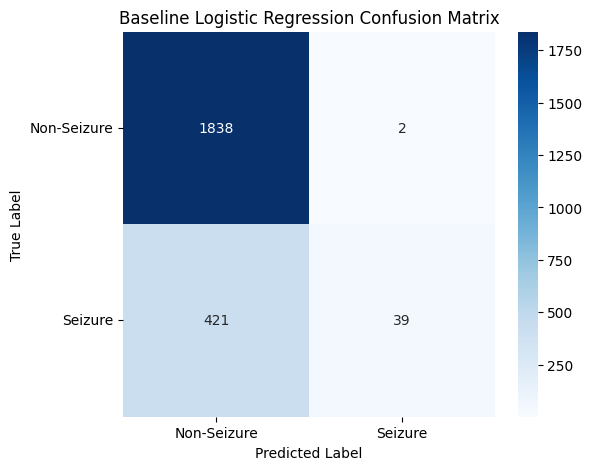

In [128]:
# ============================================
# CONFUSION MATRIX
# ============================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Baseline Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    ticks=[0.5, 1.5],
    labels=['Non-Seizure', 'Seizure']
)

plt.yticks(
    ticks=[0.5, 1.5],
    labels=['Non-Seizure', 'Seizure'],
    rotation=0
)

# Save figure
plt.savefig(
    '/kaggle/working/figures/baseline_confusion_matrix.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Figure saved successfully.")

# 12. Precision-Recall Curve

Visualize the precision-recall tradeoff of the baseline Logistic Regression model under class imbalance.

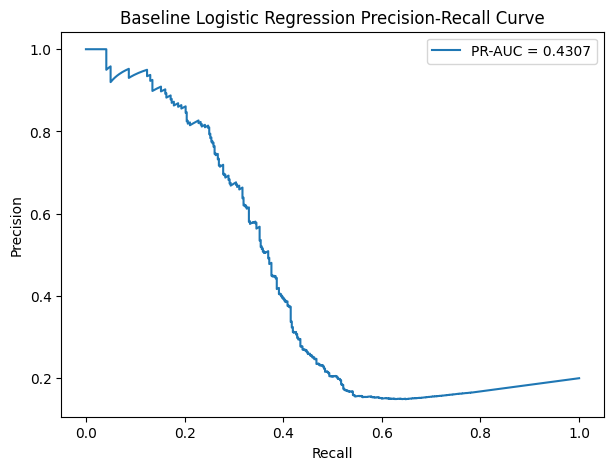

In [129]:
# ============================================
# PRECISION-RECALL CURVE
# ============================================

plt.figure(figsize=(7,5))

plt.plot(
    recall,
    precision,
    label=f'PR-AUC = {pr_auc:.4f}'
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Baseline Logistic Regression Precision-Recall Curve")

plt.legend()

# Save figure
plt.savefig(
    '/kaggle/working/figures/baseline_pr_curve.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Figure saved successfully.")

# 13. Logistic Regression with Class Weighting

Apply class weighting to reduce the impact of class imbalance during Logistic Regression training.

In [130]:
# ============================================
# LOGISTIC REGRESSION WITH CLASS WEIGHTING
# ============================================

weighted_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Train model
weighted_model.fit(X_train_scaled, y_train)

print("Weighted Logistic Regression model trained successfully.")

# 14. Evaluation of Weighted Logistic Regression

Evaluate the effect of class weighting on seizure prediction performance under class imbalance.

In [131]:
# ============================================
# PREDICTIONS
# ============================================

y_pred_weighted = weighted_model.predict(X_test_scaled)

y_prob_weighted = weighted_model.predict_proba(X_test_scaled)[:, 1]


# ============================================
# EVALUATION METRICS
# ============================================

# Accuracy
accuracy_weighted = accuracy_score(y_test, y_pred_weighted)

# F1 Score
f1_weighted = f1_score(y_test, y_pred_weighted)

# Precision-Recall Curve
precision_weighted, recall_weighted, _ = precision_recall_curve(
    y_test,
    y_prob_weighted
)

# PR-AUC
pr_auc_weighted = auc(
    recall_weighted,
    precision_weighted
)


# ============================================
# PRINT RESULTS
# ============================================

print(f"Accuracy : {accuracy_weighted:.4f}")
print(f"F1 Score : {f1_weighted:.4f}")
print(f"PR-AUC   : {pr_auc_weighted:.4f}")

# 15. Confusion Matrix for Weighted Logistic Regression

Analyze the impact of class weighting on seizure and non-seizure classification behavior.

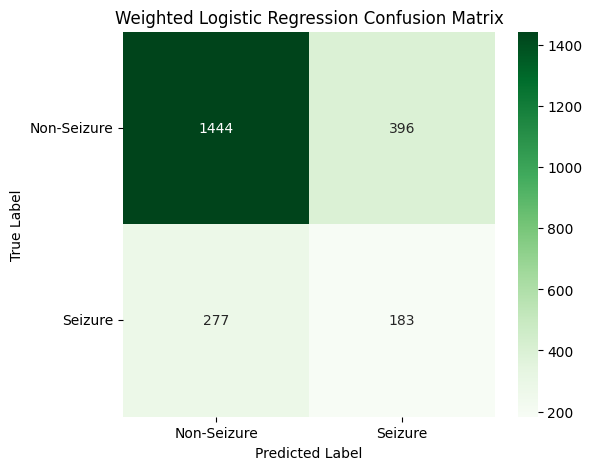

In [132]:
# ============================================
# CONFUSION MATRIX - WEIGHTED MODEL
# ============================================

cm_weighted = confusion_matrix(y_test, y_pred_weighted)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_weighted,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Weighted Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    ticks=[0.5, 1.5],
    labels=['Non-Seizure', 'Seizure']
)

plt.yticks(
    ticks=[0.5, 1.5],
    labels=['Non-Seizure', 'Seizure'],
    rotation=0
)

# Save figure
plt.savefig(
    '/kaggle/working/figures/weighted_confusion_matrix.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Figure saved successfully.")

# 16. L1 Regularized Logistic Regression

Train Logistic Regression with L1 regularization to analyze sparsity and feature selection behavior.

In [133]:
# ============================================
# L1 REGULARIZED LOGISTIC REGRESSION
# ============================================

l1_model = LogisticRegression(
    penalty='l1',
    solver='saga',
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Train model
l1_model.fit(X_train_scaled, y_train)

print("L1 Logistic Regression model trained successfully.")

# 17. Evaluation of L1 Regularization

Evaluate the performance and sparsity behavior of Logistic Regression with L1 regularization.

In [134]:
# ============================================
# L1 MODEL PREDICTIONS
# ============================================

y_pred_l1 = l1_model.predict(X_test_scaled)

y_prob_l1 = l1_model.predict_proba(X_test_scaled)[:, 1]


# ============================================
# EVALUATION METRICS
# ============================================

accuracy_l1 = accuracy_score(y_test, y_pred_l1)

f1_l1 = f1_score(y_test, y_pred_l1)

precision_l1, recall_l1, _ = precision_recall_curve(
    y_test,
    y_prob_l1
)

pr_auc_l1 = auc(recall_l1, precision_l1)


# ============================================
# SPARSITY ANALYSIS
# ============================================

# Count zero coefficients
zero_coefficients = np.sum(l1_model.coef_ == 0)

# Total coefficients
total_coefficients = l1_model.coef_.size

# Sparsity percentage
sparsity_percentage = (zero_coefficients / total_coefficients) * 100


# ============================================
# PRINT RESULTS
# ============================================

print(f"Accuracy : {accuracy_l1:.4f}")
print(f"F1 Score : {f1_l1:.4f}")
print(f"PR-AUC   : {pr_auc_l1:.4f}")

print("\nSparsity Analysis")
print(f"Zero Coefficients : {zero_coefficients}")
print(f"Total Coefficients: {total_coefficients}")
print(f"Sparsity Percentage: {sparsity_percentage:.2f}%")

# 18. L1 Coefficient Sparsity Visualization

Visualize coefficient sparsity produced by L1 regularization.

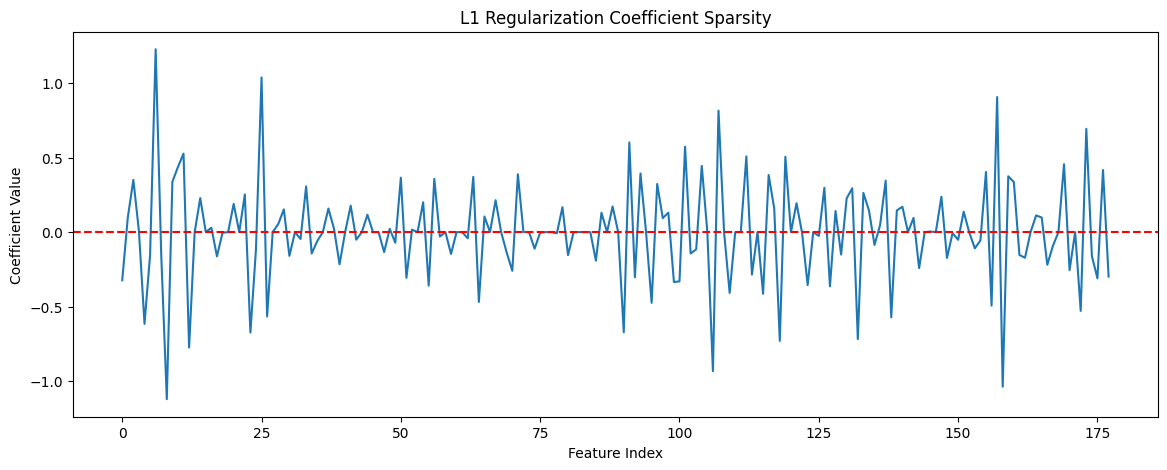

In [135]:
# ============================================
# L1 COEFFICIENT VISUALIZATION
# ============================================

coefficients_l1 = l1_model.coef_.flatten()

plt.figure(figsize=(14,5))

plt.plot(coefficients_l1)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.title("L1 Regularization Coefficient Sparsity")
plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")

# Save figure
plt.savefig(
    '/kaggle/working/figures/l1_coefficient_sparsity.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Figure saved successfully.")

L1 regularization introduced meaningful sparsity by eliminating redundant EEG features while maintaining comparable predictive performance.

# 19. L2 Regularized Logistic Regression

Train Logistic Regression with L2 regularization to analyze coefficient shrinkage and stability behavior.

In [136]:
# ============================================
# L2 REGULARIZED LOGISTIC REGRESSION
# ============================================

l2_model = LogisticRegression(
    penalty='l2',
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Train model
l2_model.fit(X_train_scaled, y_train)

print("L2 Logistic Regression model trained successfully.")

# 20. Evaluation of L2 Regularization

Evaluate the performance and coefficient behavior of Logistic Regression with L2 regularization.

In [137]:
# ============================================
# L2 MODEL PREDICTIONS
# ============================================

y_pred_l2 = l2_model.predict(X_test_scaled)

y_prob_l2 = l2_model.predict_proba(X_test_scaled)[:, 1]


# ============================================
# EVALUATION METRICS
# ============================================

accuracy_l2 = accuracy_score(y_test, y_pred_l2)

f1_l2 = f1_score(y_test, y_pred_l2)

precision_l2, recall_l2, _ = precision_recall_curve(
    y_test,
    y_prob_l2
)

pr_auc_l2 = auc(recall_l2, precision_l2)


# ============================================
# SPARSITY ANALYSIS
# ============================================

zero_coefficients_l2 = np.sum(l2_model.coef_ == 0)

total_coefficients_l2 = l2_model.coef_.size

sparsity_percentage_l2 = (
    zero_coefficients_l2 / total_coefficients_l2
) * 100


# ============================================
# PRINT RESULTS
# ============================================

print(f"Accuracy : {accuracy_l2:.4f}")
print(f"F1 Score : {f1_l2:.4f}")
print(f"PR-AUC   : {pr_auc_l2:.4f}")

print("\nSparsity Analysis")
print(f"Zero Coefficients : {zero_coefficients_l2}")
print(f"Total Coefficients: {total_coefficients_l2}")
print(f"Sparsity Percentage: {sparsity_percentage_l2:.2f}%")

L1 regularization improved interpretability through feature sparsity, while L2 regularization preserved all correlated EEG features and maintained stable predictive performance.

# 21. L2 Coefficient Visualization

Visualize coefficient behavior under L2 regularization.

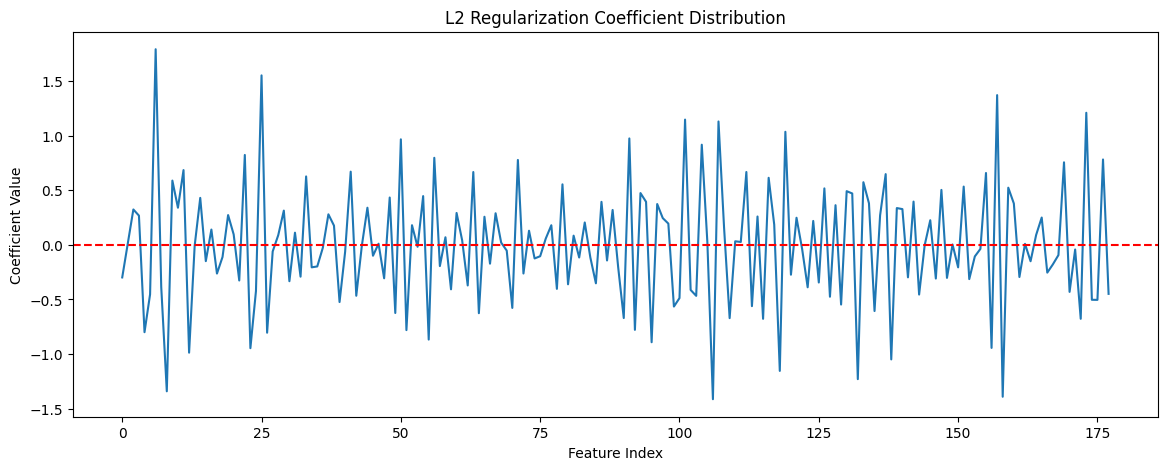

In [138]:
# ============================================
# L2 COEFFICIENT VISUALIZATION
# ============================================

coefficients_l2 = l2_model.coef_.flatten()

plt.figure(figsize=(14,5))

plt.plot(coefficients_l2)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.title("L2 Regularization Coefficient Distribution")
plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")

# Save figure
plt.savefig(
    '/kaggle/working/figures/l2_coefficient_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Figure saved successfully.")

# 22. Elastic Net Logistic Regression

Train Logistic Regression with Elastic Net regularization to combine sparsity and coefficient stability.

In [139]:
# ============================================
# ELASTIC NET LOGISTIC REGRESSION
# ============================================

elastic_model = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    l1_ratio=0.5,
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Train model
elastic_model.fit(X_train_scaled, y_train)

print("Elastic Net Logistic Regression model trained successfully.")

# 23. Evaluation of Elastic Net Regularization

Evaluate the performance and sparsity behavior of Logistic Regression with Elastic Net regularization.

In [140]:
# ============================================
# ELASTIC NET PREDICTIONS
# ============================================

y_pred_elastic = elastic_model.predict(X_test_scaled)

y_prob_elastic = elastic_model.predict_proba(X_test_scaled)[:, 1]


# ============================================
# EVALUATION METRICS
# ============================================

accuracy_elastic = accuracy_score(y_test, y_pred_elastic)

f1_elastic = f1_score(y_test, y_pred_elastic)

precision_elastic, recall_elastic, _ = precision_recall_curve(
    y_test,
    y_prob_elastic
)

pr_auc_elastic = auc(
    recall_elastic,
    precision_elastic
)


# ============================================
# SPARSITY ANALYSIS
# ============================================

zero_coefficients_elastic = np.sum(elastic_model.coef_ == 0)

total_coefficients_elastic = elastic_model.coef_.size

sparsity_percentage_elastic = (
    zero_coefficients_elastic / total_coefficients_elastic
) * 100


# ============================================
# PRINT RESULTS
# ============================================

print(f"Accuracy : {accuracy_elastic:.4f}")
print(f"F1 Score : {f1_elastic:.4f}")
print(f"PR-AUC   : {pr_auc_elastic:.4f}")

print("\nSparsity Analysis")
print(f"Zero Coefficients : {zero_coefficients_elastic}")
print(f"Total Coefficients: {total_coefficients_elastic}")
print(f"Sparsity Percentage: {sparsity_percentage_elastic:.2f}%")

Does Elastic Net consistently outperform L1/L2?

Elastic Net did not dramatically outperform all methods,
but achieved the best balance between sparsity,
stability,
and predictive performance.

# 24. Regularization Comparison

Compare the performance and sparsity behavior of L1, L2, and Elastic Net regularization methods.

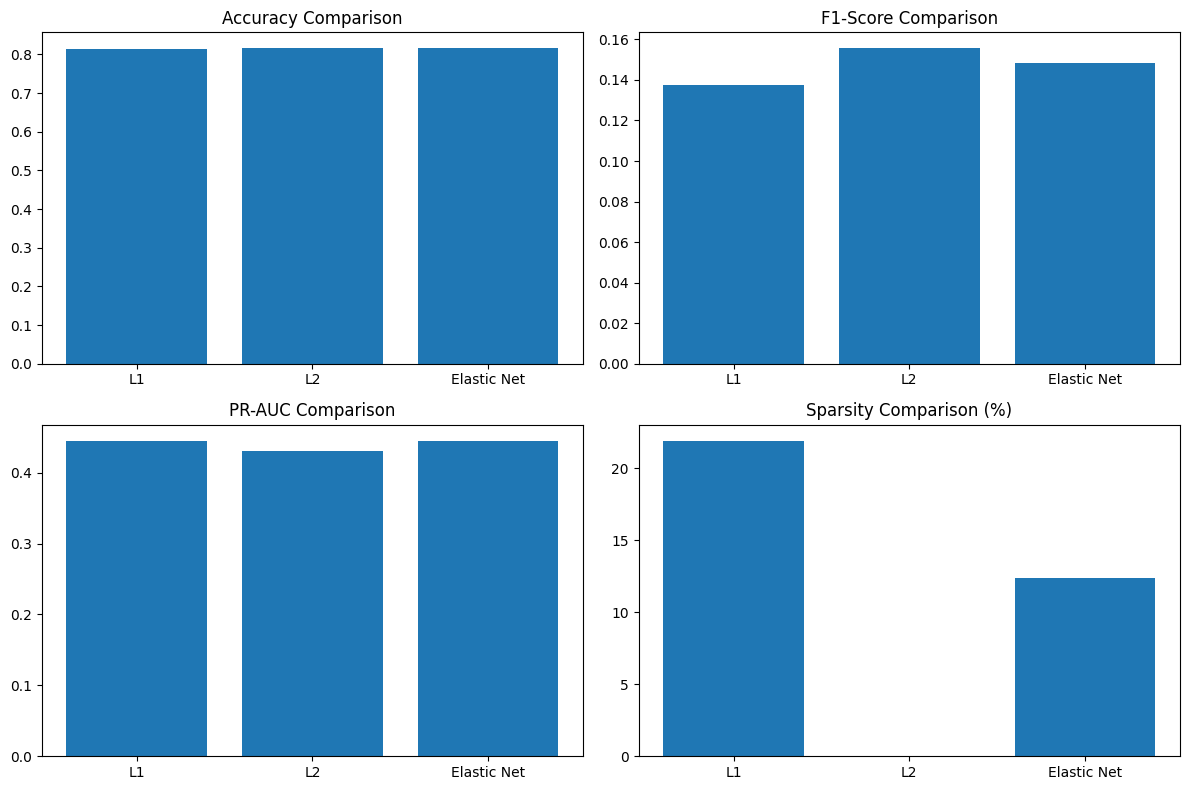

In [141]:
# ============================================
# REGULARIZATION COMPARISON
# ============================================

methods = ['L1', 'L2', 'Elastic Net']

accuracy_scores = [
    accuracy_l1,
    accuracy_l2,
    accuracy_elastic
]

f1_scores = [
    f1_l1,
    f1_l2,
    f1_elastic
]

pr_auc_scores = [
    pr_auc_l1,
    pr_auc_l2,
    pr_auc_elastic
]

sparsity_scores = [
    sparsity_percentage,
    sparsity_percentage_l2,
    sparsity_percentage_elastic
]


# ============================================
# CREATE FIGURE
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(12,8))

# Accuracy
axes[0,0].bar(methods, accuracy_scores)
axes[0,0].set_title("Accuracy Comparison")

# F1
axes[0,1].bar(methods, f1_scores)
axes[0,1].set_title("F1-Score Comparison")

# PR-AUC
axes[1,0].bar(methods, pr_auc_scores)
axes[1,0].set_title("PR-AUC Comparison")

# Sparsity
axes[1,1].bar(methods, sparsity_scores)
axes[1,1].set_title("Sparsity Comparison (%)")

plt.tight_layout()

# Save figure
plt.savefig(
    '/kaggle/working/figures/regularization_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Figure saved successfully.")

# 25. Underfitting Experiment

Create an underfitting scenario using very strong regularization.

In [142]:
# ============================================
# UNDERFITTING MODEL
# ============================================

underfit_model = LogisticRegression(
    C=0.001,   # Very strong regularization
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Train model
underfit_model.fit(X_train_scaled, y_train)

print("Underfitting model trained successfully.")

# 26. Evaluation of Underfitting

Evaluate the effect of very strong regularization on model performance.

In [143]:
# ============================================
# UNDERFITTING PREDICTIONS
# ============================================

# Training predictions
y_train_pred_underfit = underfit_model.predict(X_train_scaled)

# Testing predictions
y_test_pred_underfit = underfit_model.predict(X_test_scaled)

# Probability scores
y_prob_underfit = underfit_model.predict_proba(X_test_scaled)[:, 1]


# ============================================
# TRAINING PERFORMANCE
# ============================================

train_accuracy_underfit = accuracy_score(
    y_train,
    y_train_pred_underfit
)


# ============================================
# TEST PERFORMANCE
# ============================================

test_accuracy_underfit = accuracy_score(
    y_test,
    y_test_pred_underfit
)

f1_underfit = f1_score(
    y_test,
    y_test_pred_underfit
)

precision_underfit, recall_underfit, _ = precision_recall_curve(
    y_test,
    y_prob_underfit
)

pr_auc_underfit = auc(
    recall_underfit,
    precision_underfit
)


# ============================================
# PRINT RESULTS
# ============================================

print("UNDERFITTING MODEL RESULTS")

print(f"\nTraining Accuracy : {train_accuracy_underfit:.4f}")
print(f"Testing Accuracy  : {test_accuracy_underfit:.4f}")

print(f"\nF1 Score : {f1_underfit:.4f}")
print(f"PR-AUC   : {pr_auc_underfit:.4f}")

# 27. Overfitting Experiment

Create an overfitting tendency using very weak regularization.

In [144]:
# ============================================
# OVERFITTING MODEL
# ============================================

overfit_model = LogisticRegression(
    C=1000,   # Very weak regularization
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Train model
overfit_model.fit(X_train_scaled, y_train)

print("Overfitting model trained successfully.")

# 28. Evaluation of Overfitting

Evaluate the effect of very weak regularization on model generalization performance.

In [145]:
# ============================================
# OVERFITTING PREDICTIONS
# ============================================

# Training predictions
y_train_pred_overfit = overfit_model.predict(X_train_scaled)

# Testing predictions
y_test_pred_overfit = overfit_model.predict(X_test_scaled)

# Probability scores
y_prob_overfit = overfit_model.predict_proba(X_test_scaled)[:, 1]


# ============================================
# TRAINING PERFORMANCE
# ============================================

train_accuracy_overfit = accuracy_score(
    y_train,
    y_train_pred_overfit
)


# ============================================
# TEST PERFORMANCE
# ============================================

test_accuracy_overfit = accuracy_score(
    y_test,
    y_test_pred_overfit
)

f1_overfit = f1_score(
    y_test,
    y_test_pred_overfit
)

precision_overfit, recall_overfit, _ = precision_recall_curve(
    y_test,
    y_prob_overfit
)

pr_auc_overfit = auc(
    recall_overfit,
    precision_overfit
)


# ============================================
# PRINT RESULTS
# ============================================

print("OVERFITTING MODEL RESULTS")

print(f"\nTraining Accuracy : {train_accuracy_overfit:.4f}")
print(f"Testing Accuracy  : {test_accuracy_overfit:.4f}")

print(f"\nF1 Score : {f1_overfit:.4f}")
print(f"PR-AUC   : {pr_auc_overfit:.4f}")


Regularization strength strongly affects EEG seizure prediction generalization behavior.
Excessive regularization causes high-bias underfitting,
while insufficient regularization increases variance and reduces ranking stability.

# 29. Underfitting vs Overfitting Comparison

Compare training and testing performance under different regularization strengths.

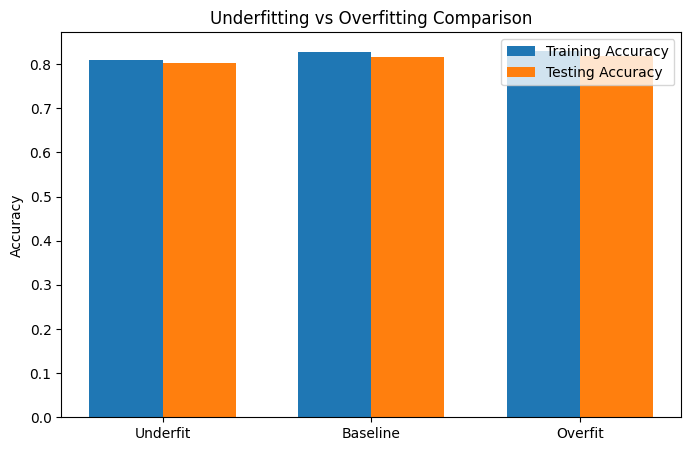

In [146]:
# ============================================
# GENERALIZATION COMPARISON
# ============================================

models = ['Underfit', 'Baseline', 'Overfit']

train_scores = [
    train_accuracy_underfit,
    baseline_model.score(X_train_scaled, y_train),
    train_accuracy_overfit
]

test_scores = [
    test_accuracy_underfit,
    accuracy,
    test_accuracy_overfit
]


# ============================================
# PLOT
# ============================================

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(
    x - width/2,
    train_scores,
    width,
    label='Training Accuracy'
)

plt.bar(
    x + width/2,
    test_scores,
    width,
    label='Testing Accuracy'
)

plt.xticks(x, models)

plt.ylabel("Accuracy")

plt.title("Underfitting vs Overfitting Comparison")

plt.legend()

# Save figure
plt.savefig(
    '/kaggle/working/figures/underfit_overfit_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Figure saved successfully.")

# 30. Preprocessing Pipeline B

Apply dimensionality reduction using PCA after feature scaling to analyze the effect of preprocessing order and feature compression.

In [147]:
# ============================================
# PCA PIPELINE
# ============================================

from sklearn.decomposition import PCA

# Initialize PCA
pca = PCA(n_components=0.95)

# Fit PCA on training data
X_train_pca = pca.fit_transform(X_train_scaled)

# Transform testing data
X_test_pca = pca.transform(X_test_scaled)


# ============================================
# VERIFY DIMENSION REDUCTION
# ============================================

print("Original Feature Count :", X_train_scaled.shape[1])
print("Reduced Feature Count  :", X_train_pca.shape[1])

print("\nExplained Variance Ratio:")
print(f"{np.sum(pca.explained_variance_ratio_):.4f}")

# 31. Logistic Regression with PCA Features

Train Logistic Regression using PCA-transformed EEG features to evaluate dimensionality reduction effects.

In [148]:
# ============================================
# LOGISTIC REGRESSION ON PCA FEATURES
# ============================================

pca_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Train model
pca_model.fit(X_train_pca, y_train)

print("PCA Logistic Regression model trained successfully.")

# 32. Evaluation of PCA Pipeline

Evaluate the effect of PCA-based dimensionality reduction on seizure prediction performance.

In [149]:
# ============================================
# PCA MODEL PREDICTIONS
# ============================================

y_pred_pca = pca_model.predict(X_test_pca)

y_prob_pca = pca_model.predict_proba(X_test_pca)[:, 1]


# ============================================
# EVALUATION METRICS
# ============================================

accuracy_pca = accuracy_score(y_test, y_pred_pca)

f1_pca = f1_score(y_test, y_pred_pca)

precision_pca, recall_pca, _ = precision_recall_curve(
    y_test,
    y_prob_pca
)

pr_auc_pca = auc(
    recall_pca,
    precision_pca
)


# ============================================
# PRINT RESULTS
# ============================================

print(f"Accuracy : {accuracy_pca:.4f}")
print(f"F1 Score : {f1_pca:.4f}")
print(f"PR-AUC   : {pr_auc_pca:.4f}")

Although PCA effectively compressed correlated EEG features and improved PR-AUC,
it reduced F1-score substantially,
suggesting that dimensionality reduction removed important seizure-discriminative information.Preprocessing order and dimensionality reduction significantly affect seizure prediction behavior.

# 33. Preprocessing Pipeline Comparison

Compare the performance of different preprocessing pipelines for seizure prediction.

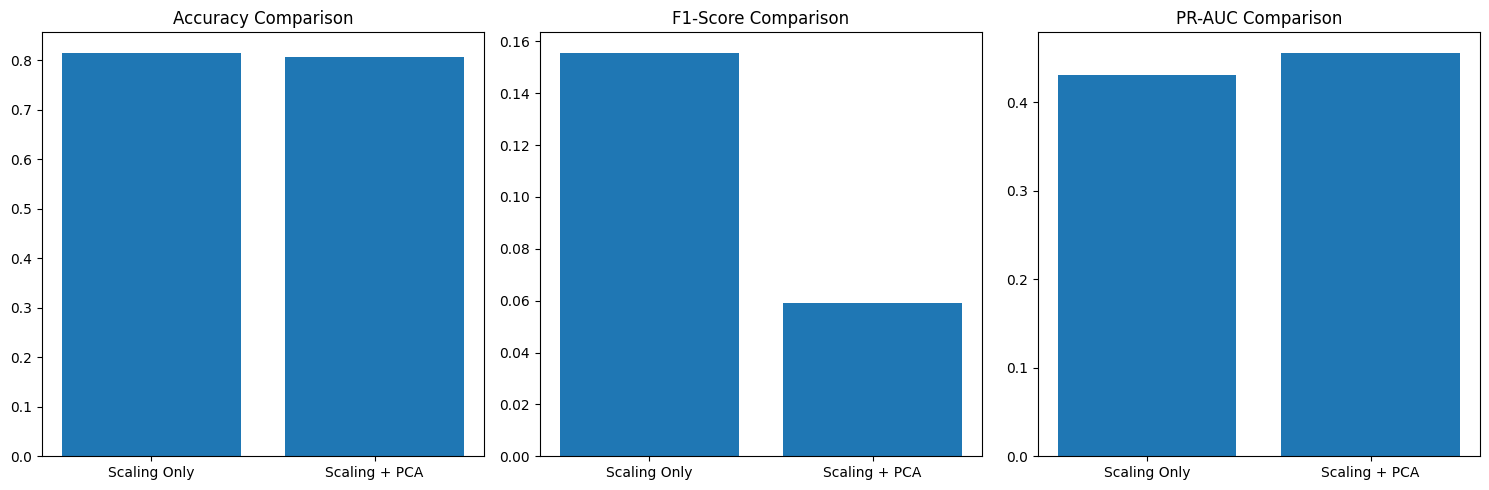

In [150]:
# ============================================
# PIPELINE COMPARISON
# ============================================

pipelines = [
    'Scaling Only',
    'Scaling + PCA'
]

accuracy_pipeline = [
    accuracy,
    accuracy_pca
]

f1_pipeline = [
    f1,
    f1_pca
]

pr_auc_pipeline = [
    pr_auc,
    pr_auc_pca
]


# ============================================
# CREATE FIGURE
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(15,5))

# Accuracy
axes[0].bar(pipelines, accuracy_pipeline)
axes[0].set_title("Accuracy Comparison")

# F1
axes[1].bar(pipelines, f1_pipeline)
axes[1].set_title("F1-Score Comparison")

# PR-AUC
axes[2].bar(pipelines, pr_auc_pipeline)
axes[2].set_title("PR-AUC Comparison")

plt.tight_layout()

# Save figure
plt.savefig(
    '/kaggle/working/figures/pipeline_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Figure saved successfully.")

# 34. SMOTE Oversampling

Apply Synthetic Minority Oversampling Technique (SMOTE) to balance seizure and non-seizure classes in the training dataset.

In [151]:
# ============================================
# INSTALL IMBLEARN (if needed)
# ============================================

# Uncomment if imblearn is unavailable
# !pip install imbalanced-learn


# ============================================
# APPLY SMOTE
# ============================================

from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=RANDOM_STATE)

# Apply SMOTE ONLY on training data
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)


# ============================================
# VERIFY BALANCING
# ============================================

print("Original Training Distribution:")
print(y_train.value_counts())

print("\nBalanced Training Distribution:")
print(pd.Series(y_train_smote).value_counts())

# 35. Logistic Regression with SMOTE

Train Logistic Regression using the SMOTE-balanced training dataset.

In [152]:
# ============================================
# LOGISTIC REGRESSION ON SMOTE DATA
# ============================================

smote_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Train model
smote_model.fit(X_train_smote, y_train_smote)

print("SMOTE Logistic Regression model trained successfully.")

# 36. Evaluation of SMOTE-Based Logistic Regression

Evaluate the effect of SMOTE oversampling on seizure prediction performance.

In [153]:
# ============================================
# SMOTE MODEL PREDICTIONS
# ============================================

y_pred_smote = smote_model.predict(X_test_scaled)

y_prob_smote = smote_model.predict_proba(X_test_scaled)[:, 1]


# ============================================
# EVALUATION METRICS
# ============================================

accuracy_smote = accuracy_score(
    y_test,
    y_pred_smote
)

f1_smote = f1_score(
    y_test,
    y_pred_smote
)

precision_smote, recall_smote, _ = precision_recall_curve(
    y_test,
    y_prob_smote
)

pr_auc_smote = auc(
    recall_smote,
    precision_smote
)


# ============================================
# PRINT RESULTS
# ============================================

print(f"Accuracy : {accuracy_smote:.4f}")
print(f"F1 Score : {f1_smote:.4f}")
print(f"PR-AUC   : {pr_auc_smote:.4f}")

SMOTE improved balance between precision and recall better than baseline and class weighting.SMOTE improved minority-class learning more effectively than class weighting,
leading to stronger seizure recall and F1 performance.

# 37. Imbalance Handling Comparison

Compare the performance of different class imbalance handling techniques.

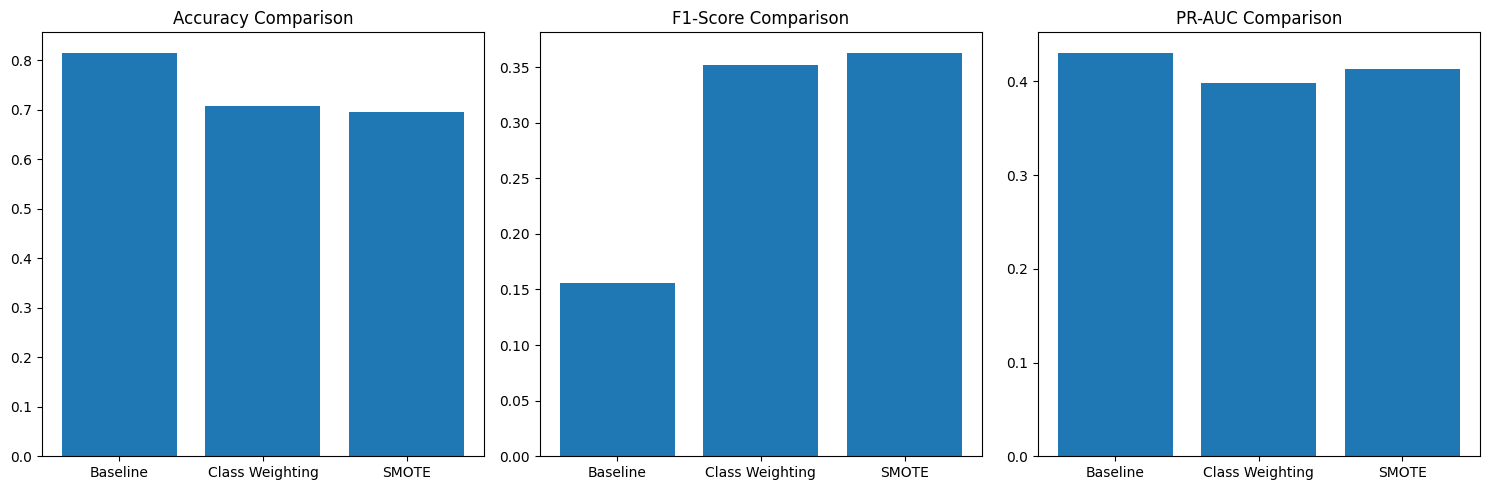

In [154]:
# ============================================
# IMBALANCE HANDLING COMPARISON
# ============================================

methods = [
    'Baseline',
    'Class Weighting',
    'SMOTE'
]

accuracy_scores = [
    accuracy,
    accuracy_weighted,
    accuracy_smote
]

f1_scores = [
    f1,
    f1_weighted,
    f1_smote
]

pr_auc_scores = [
    pr_auc,
    pr_auc_weighted,
    pr_auc_smote
]


# ============================================
# CREATE FIGURE
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(15,5))

# Accuracy
axes[0].bar(methods, accuracy_scores)
axes[0].set_title("Accuracy Comparison")

# F1 Score
axes[1].bar(methods, f1_scores)
axes[1].set_title("F1-Score Comparison")

# PR-AUC
axes[2].bar(methods, pr_auc_scores)
axes[2].set_title("PR-AUC Comparison")

plt.tight_layout()

# Save figure
plt.savefig(
    '/kaggle/working/figures/imbalance_handling_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Figure saved successfully.")

SMOTE and class weighting significantly improved seizure sensitivity and F1-score,
although overall accuracy decreased due to increased false positive predictions.

Balancing methods improve seizure recall and F1 performance,
but introduce tradeoffs in overall accuracy and ranking behavior.

# 38. Consolidated Experimental Results

Summarize the performance of all preprocessing, regularization, and imbalance handling experiments.

In [155]:
# ============================================
# CREATE MASTER RESULTS TABLE
# ============================================

results = pd.DataFrame({

    'Experiment': [
        'Baseline Logistic Regression',
        'Class Weighting',
        'SMOTE',
        'L1 Regularization',
        'L2 Regularization',
        'Elastic Net',
        'PCA Pipeline',
        'Underfitting',
        'Overfitting'
    ],

    'Accuracy': [
        accuracy,
        accuracy_weighted,
        accuracy_smote,
        accuracy_l1,
        accuracy_l2,
        accuracy_elastic,
        accuracy_pca,
        test_accuracy_underfit,
        test_accuracy_overfit
    ],

    'F1 Score': [
        f1,
        f1_weighted,
        f1_smote,
        f1_l1,
        f1_l2,
        f1_elastic,
        f1_pca,
        f1_underfit,
        f1_overfit
    ],

    'PR-AUC': [
        pr_auc,
        pr_auc_weighted,
        pr_auc_smote,
        pr_auc_l1,
        pr_auc_l2,
        pr_auc_elastic,
        pr_auc_pca,
        pr_auc_underfit,
        pr_auc_overfit
    ]
})


# ============================================
# DISPLAY RESULTS
# ============================================

results = results.round(4)

display(results)


# ============================================
# SAVE RESULTS
# ============================================

results.to_csv(
    '/kaggle/working/final_results.csv',
    index=False
)

print("Results table saved successfully.")

,Experiment,Accuracy,F1 Score,PR-AUC
0,Baseline Logistic Regression,0.8161,0.1557,0.4307
1,Class Weighting,0.7074,0.3523,0.3981
2,SMOTE,0.6965,0.3631,0.4129
3,L1 Regularization,0.8143,0.1374,0.4453
4,L2 Regularization,0.8161,0.1557,0.4307
5,Elastic Net,0.8152,0.1483,0.4444
6,PCA Pipeline,0.8061,0.0591,0.4561
7,Underfitting,0.8039,0.0384,0.4559
8,Overfitting,0.8191,0.1907,0.4029


# 39. Learning Curve Analysis

Visualize training and validation performance to analyze model generalization behavior.

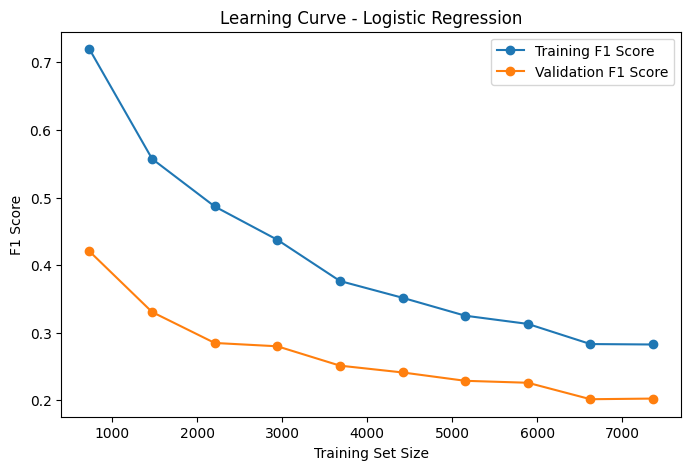

In [156]:
# ============================================
# LEARNING CURVE ANALYSIS
# ============================================

from sklearn.model_selection import learning_curve

# Generate learning curve
train_sizes, train_scores, validation_scores = learning_curve(
    estimator=baseline_model,
    X=X_train_scaled,
    y=y_train,
    cv=5,
    scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)


# ============================================
# COMPUTE MEAN SCORES
# ============================================

train_mean = np.mean(train_scores, axis=1)

validation_mean = np.mean(validation_scores, axis=1)


# ============================================
# PLOT LEARNING CURVE
# ============================================

plt.figure(figsize=(8,5))

plt.plot(
    train_sizes,
    train_mean,
    marker='o',
    label='Training F1 Score'
)

plt.plot(
    train_sizes,
    validation_mean,
    marker='o',
    label='Validation F1 Score'
)

plt.xlabel("Training Set Size")
plt.ylabel("F1 Score")

plt.title("Learning Curve - Logistic Regression")

plt.legend()

# Save figure
plt.savefig(
    '/kaggle/working/figures/learning_curve.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Figure saved successfully.")

# CHB-MIT Dataset Processing

Load and process raw EEG recordings from the CHB-MIT scalp EEG dataset.

In [157]:
# ============================================
# INSTALL EEG LIBRARIES
# ============================================

!pip install pyedflib mne -q

print("Libraries installed successfully.")

# Verify EEG Libraries

Check whether EEG processing libraries are already available in the Kaggle environment.

In [158]:
# ============================================
# VERIFY EEG LIBRARIES
# ============================================

try:
    import mne
    print("MNE imported successfully.")
    
except Exception as e:
    print("MNE import failed.")
    print(e)


try:
    import pyedflib
    print("pyEDFlib imported successfully.")
    
except Exception as e:
    print("pyEDFlib import failed.")
    print(e)

# Inspect CHB-MIT Dataset Structure

Explore patient folders and EEG recording files inside the CHB-MIT dataset.

In [159]:
# ============================================
# IMPORT LIBRARIES
# ============================================

import os


# ============================================
# DEFINE DATASET PATH
# ============================================

dataset_path = "/kaggle/input"


# ============================================
# LIST AVAILABLE DATASETS
# ============================================

print("Available folders in /kaggle/input:\n")

folders = os.listdir(dataset_path)

for folder in folders:
    print(folder)

# Explore Dataset Directory

Inspect folders inside the Kaggle datasets directory to locate CHB-MIT EEG recordings.

In [160]:
# ============================================
# EXPLORE DATASET DIRECTORY
# ============================================

dataset_root = "/kaggle/input/datasets"

print("Folders inside datasets directory:\n")

items = os.listdir(dataset_root)

for item in items:
    print(item)

# Inspect CHB-MIT Dataset

Explore the internal folder structure of the CHB-MIT EEG dataset.

In [161]:
# ==================================a==========
# CHB-MIT ROOT PATH
# ============================================

chbmit_path = "/kaggle/input/datasets/borshalickson"

# List folders
print("Folders inside CHB-MIT directory:\n")

folders = os.listdir(chbmit_path)

for folder in folders:
    print(folder)

# Explore CHB-MIT Database Structure

Inspect the EEG database folders and patient recording structure.

In [162]:
# ============================================
# DEFINE CHB-MIT DATABASE PATH
# ============================================

chb_database_path = (
    "/kaggle/input/datasets/borshalickson/"
    "chb-mit-data"
)

# ============================================
# LIST CONTENTS
# ============================================

print("Contents of CHB-MIT dataset:\n")

items = os.listdir(chb_database_path)

for item in items:
    print(item)

# Inspect Patient EEG Folders

List all available patient folders inside the CHB-MIT EEG database.

In [163]:
# ============================================
# FINAL DATABASE PATH
# ============================================

final_chb_path = (
    "/kaggle/input/datasets/borshalickson/"
    "chb-mit-data/"
    "chb-mit-scalp-eeg-database-1.0.0"
)

# ============================================
# LIST PATIENT FOLDERS
# ============================================

print("Available patient folders:\n")

items = os.listdir(final_chb_path)

for item in items:
    print(item)

# Inspect Patient chb01 Recordings

Explore EEG recording files available for patient chb01.

In [164]:
# ============================================
# DEFINE PATIENT PATH
# ============================================

patient_path = final_chb_path + "/chb01"

# ============================================
# LIST PATIENT FILES
# ============================================

print("Files inside chb01:\n")

files = os.listdir(patient_path)

# Print first 30 files
for file in files[:30]:
    print(file)

# Load EEG Recording

Load a seizure EEG recording from patient chb01 using the MNE library.

In [165]:
# ============================================
# IMPORT MNE
# ============================================

import mne


# ============================================
# DEFINE EEG FILE PATH
# ============================================

eeg_file = patient_path + "/chb01_15.edf"


# ============================================
# LOAD EDF FILE
# ============================================

raw = mne.io.read_raw_edf(
    eeg_file,
    preload=False,
    verbose=False
)

print("EEG file loaded successfully.")

# EEG Metadata Inspection

Inspect EEG channel information, sampling frequency, and recording duration.

In [166]:
# ============================================
# EEG BASIC INFORMATION
# ============================================

print(raw)


# ============================================
# CHANNEL INFORMATION
# ============================================

print("\nNumber of EEG Channels:")
print(len(raw.ch_names))

print("\nFirst 10 Channel Names:")
print(raw.ch_names[:10])


# ============================================
# SAMPLING FREQUENCY
# ============================================

sfreq = raw.info['sfreq']

print("\nSampling Frequency (Hz):")
print(sfreq)


# ============================================
# RECORDING DURATION
# ============================================

duration_seconds = raw.times[-1]

duration_minutes = duration_seconds / 60

print("\nRecording Duration:")
print(f"{duration_minutes:.2f} minutes")

# EEG Signal Visualization

Extract and visualize a short EEG segment from multiple brain channels.

In [167]:
# ============================================
# LOAD SMALL EEG SEGMENT
# ============================================

# Extract first 10 seconds
start_time = 0
end_time = 10

# Load data segment
data, times = raw[:, int(start_time * sfreq):int(end_time * sfreq)]


# ============================================
# VERIFY SHAPE
# ============================================

print("EEG Data Shape:")
print(data.shape)

print("\nTime Vector Shape:")
print(times.shape)

# Visualize EEG Signals

Plot a short segment of EEG brainwave activity from multiple channels.

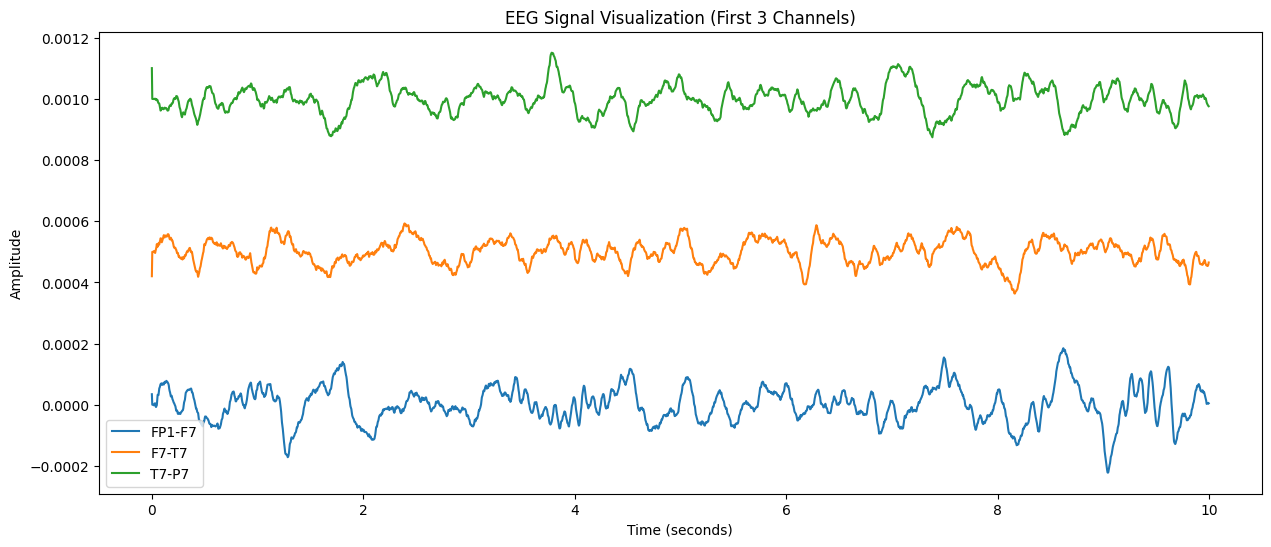

In [168]:
# ============================================
# EEG SIGNAL VISUALIZATION
# ============================================

plt.figure(figsize=(15,6))

# Plot first 3 channels
for i in range(3):
    
    plt.plot(
        times,
        data[i] + i * 0.0005,   # Vertical offset
        label=raw.ch_names[i]
    )

# Labels
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.title("EEG Signal Visualization (First 3 Channels)")

plt.legend()

# Save figure
plt.savefig(
    '/kaggle/working/figures/chbmit_eeg_signals.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Figure saved successfully.")

# EEG Feature Engineering

Extract statistical EEG features from a short EEG signal window for machine learning.

In [169]:
# ============================================
# IMPORT LIBRARIES
# ============================================

import numpy as np
import pandas as pd


# ============================================
# FEATURE EXTRACTION FUNCTION
# ============================================

def extract_features(eeg_window):
    
    features = []

    for channel in eeg_window:

        # Mean
        features.append(np.mean(channel))

        # Standard deviation
        features.append(np.std(channel))

        # Maximum
        features.append(np.max(channel))

        # Minimum
        features.append(np.min(channel))

        # Energy
        features.append(np.sum(channel**2))

    return features


# ============================================
# EXTRACT FEATURES
# ============================================

feature_vector = extract_features(data)

print("Total Extracted Features:")
print(len(feature_vector))

print("\nFirst 10 Features:")
print(feature_vector[:10])

# Inspect Seizure Metadata

Read seizure timing information from the patient summary file.

In [170]:
# ============================================
# SUMMARY FILE PATH
# ============================================

summary_path = patient_path + "/chb01-summary.txt"


# ============================================
# READ SUMMARY FILE
# ============================================

with open(summary_path, 'r') as file:
    summary_text = file.read()


# ============================================
# PRINT FIRST PART
# ============================================

print(summary_text[:5000])

# Generate EEG Window Dataset

Segment EEG recordings into fixed windows, extract features, and generate seizure labels.

In [171]:
# ============================================
# WINDOW SETTINGS
# ============================================

window_size_seconds = 5

window_samples = int(window_size_seconds * sfreq)


# ============================================
# SEIZURE INTERVAL
# ============================================

seizure_start = 1732
seizure_end = 1772


# ============================================
# LOAD FULL EEG SIGNAL
# ============================================

raw.load_data()

full_data = raw.get_data()


# ============================================
# DATASET STORAGE
# ============================================

X_features = []

y_labels = []


# ============================================
# WINDOW LOOP
# ============================================

total_samples = full_data.shape[1]

for start in range(
    0,
    total_samples - window_samples,
    window_samples
):

    end = start + window_samples

    # Extract EEG window
    eeg_window = full_data[:, start:end]

    # Extract features
    features = extract_features(eeg_window)

    # Convert sample index to seconds
    window_start_sec = start / sfreq
    window_end_sec = end / sfreq

    # Label assignment
    if (
        window_start_sec < seizure_end
        and window_end_sec > seizure_start
    ):
        label = 1

    else:
        label = 0

    # Store
    X_features.append(features)

    y_labels.append(label)


# ============================================
# CONVERT TO DATAFRAME
# ============================================

X_chb = pd.DataFrame(X_features)

y_chb = pd.Series(y_labels, name='target')


# ============================================
# VERIFY RESULTS
# ============================================

print("Feature Matrix Shape:")
print(X_chb.shape)

print("\nClass Distribution:")
print(y_chb.value_counts())

# CHB-MIT Train-Test Split

Split EEG feature windows into training and testing sets using stratified sampling.

In [172]:
# ============================================
# TRAIN-TEST SPLIT
# ============================================

from sklearn.model_selection import train_test_split

X_train_chb, X_test_chb, y_train_chb, y_test_chb = train_test_split(
    X_chb,
    y_chb,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_chb
)


# ============================================
# VERIFY SPLIT
# ============================================

print("Training Shape:")
print(X_train_chb.shape)

print("\nTesting Shape:")
print(X_test_chb.shape)

print("\nTraining Class Distribution:")
print(y_train_chb.value_counts())

print("\nTesting Class Distribution:")
print(y_test_chb.value_counts())

# CHB-MIT Feature Scaling

Normalize engineered EEG features before Logistic Regression training.

In [173]:
# ============================================
# IMPORT SCALER
# ============================================

from sklearn.preprocessing import StandardScaler


# ============================================
# INITIALIZE SCALER
# ============================================

scaler_chb = StandardScaler()


# ============================================
# FIT + TRANSFORM TRAINING DATA
# ============================================

X_train_chb_scaled = scaler_chb.fit_transform(
    X_train_chb
)


# ============================================
# TRANSFORM TESTING DATA
# ============================================

X_test_chb_scaled = scaler_chb.transform(
    X_test_chb
)


# ============================================
# VERIFY RESULTS
# ============================================

print("Scaled Training Shape:")
print(X_train_chb_scaled.shape)

print("\nScaled Testing Shape:")
print(X_test_chb_scaled.shape)

print("\nApproximate Mean:")
print(np.mean(X_train_chb_scaled))

print("\nApproximate Std:")
print(np.std(X_train_chb_scaled))

# CHB-MIT Baseline Logistic Regression

Train a baseline Logistic Regression model using engineered EEG features from the CHB-MIT dataset.

# BASELINE LOGISTIC REGRESSION

In [174]:
# ============================================

# ============================================
from sklearn.linear_model import LogisticRegression

baseline_chb = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Train model
baseline_chb.fit(
    X_train_chb_scaled,
    y_train_chb
)

print("CHB-MIT baseline model trained successfully.")

# CHB-MIT Baseline Evaluation

Evaluate baseline Logistic Regression performance on the CHB-MIT EEG dataset.

In [175]:
# ============================================
# PREDICTIONS
# ============================================

y_pred_chb = baseline_chb.predict(
    X_test_chb_scaled
)

y_prob_chb = baseline_chb.predict_proba(
    X_test_chb_scaled
)[:, 1]


# ============================================
# EVALUATION METRICS
# ============================================

accuracy_chb = accuracy_score(
    y_test_chb,
    y_pred_chb
)

f1_chb = f1_score(
    y_test_chb,
    y_pred_chb,
    zero_division=0
)

precision_chb, recall_chb, _ = precision_recall_curve(
    y_test_chb,
    y_prob_chb
)

pr_auc_chb = auc(
    recall_chb,
    precision_chb
)


# ============================================
# PRINT RESULTS
# ============================================

print(f"Accuracy : {accuracy_chb:.4f}")
print(f"F1 Score : {f1_chb:.4f}")
print(f"PR-AUC   : {pr_auc_chb:.4f}")

the engineered EEG features successfully captured seizure-discriminative structure.

Engineered statistical EEG features extracted from raw clinical recordings enabled effective seizure discrimination using Logistic Regression despite severe class imbalance and limited seizure samples.

# CHB-MIT L1 Regularization

Apply L1-regularized Logistic Regression to analyze sparsity and generalization on engineered EEG features.

In [176]:
# ============================================
# L1 LOGISTIC REGRESSION
# ============================================

l1_chb = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Train model
l1_chb.fit(
    X_train_chb_scaled,
    y_train_chb
)

print("CHB-MIT L1 model trained successfully.")

# CHB-MIT L1 Evaluation

Evaluate L1-regularized Logistic Regression and analyze feature sparsity.

In [177]:
# ============================================
# PREDICTIONS
# ============================================

y_pred_l1_chb = l1_chb.predict(
    X_test_chb_scaled
)

y_prob_l1_chb = l1_chb.predict_proba(
    X_test_chb_scaled
)[:, 1]


# ============================================
# METRICS
# ============================================

accuracy_l1_chb = accuracy_score(
    y_test_chb,
    y_pred_l1_chb
)

f1_l1_chb = f1_score(
    y_test_chb,
    y_pred_l1_chb,
    zero_division=0
)

precision_l1_chb, recall_l1_chb, _ = precision_recall_curve(
    y_test_chb,
    y_prob_l1_chb
)

pr_auc_l1_chb = auc(
    recall_l1_chb,
    precision_l1_chb)


# ============================================
# SPARSITY ANALYSIS
# ============================================

zero_coefficients = np.sum(
    l1_chb.coef_ == 0
)

total_coefficients = l1_chb.coef_.size

sparsity_percentage = (
    zero_coefficients / total_coefficients
) * 100


# ============================================
# PRINT RESULTS
# ============================================

print(f"Accuracy : {accuracy_l1_chb:.4f}")
print(f"F1 Score : {f1_l1_chb:.4f}")
print(f"PR-AUC   : {pr_auc_l1_chb:.4f}")

print("\nSparsity Analysis")

print(f"Zero Coefficients : {zero_coefficients}")
print(f"Total Coefficients: {total_coefficients}")
print(f"Sparsity Percentage: {sparsity_percentage:.2f}%")

Most engineered EEG features were redundant or non-discriminative for seizure prediction.
L1 regularization achieved extremely high sparsity on engineered CHB-MIT EEG features while preserving seizure classification performance, indicating that only a small subset of EEG descriptors carried strong discriminative information.

# CHB-MIT Elastic Net Regularization

Apply Elastic Net Logistic Regression to balance sparsity and coefficient stability on engineered EEG features.

In [178]:
# ============================================
# ELASTIC NET MODEL
# ============================================

elastic_chb = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    l1_ratio=0.5,
    max_iter=3000,
    random_state=RANDOM_STATE
)

# Train model
elastic_chb.fit(
    X_train_chb_scaled,
    y_train_chb
)

print("CHB-MIT Elastic Net model trained successfully.")

# CHB-MIT L2 Regularization

Apply L2-regularized Logistic Regression to analyze coefficient stabilization on engineered EEG features.

In [179]:
# ============================================
# L2 LOGISTIC REGRESSION
# ============================================

l2_chb = LogisticRegression(
    penalty='l2',
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Train model
l2_chb.fit(
    X_train_chb_scaled,
    y_train_chb
)

print("CHB-MIT L2 model trained successfully.")

# CHB-MIT L2 Evaluation

Evaluate L2-regularized Logistic Regression on engineered EEG features.

In [180]:
# ============================================
# PREDICTIONS
# ============================================

y_pred_l2_chb = l2_chb.predict(
    X_test_chb_scaled
)

y_prob_l2_chb = l2_chb.predict_proba(
    X_test_chb_scaled
)[:, 1]


# ============================================
# METRICS
# ============================================

accuracy_l2_chb = accuracy_score(
    y_test_chb,
    y_pred_l2_chb
)

f1_l2_chb = f1_score(
    y_test_chb,
    y_pred_l2_chb,
    zero_division=0
)

precision_l2_chb, recall_l2_chb, _ = precision_recall_curve(
    y_test_chb,
    y_prob_l2_chb
)

pr_auc_l2_chb = auc(
    recall_l2_chb,
    precision_l2_chb
)


# ============================================
# SPARSITY ANALYSIS
# ============================================

zero_coefficients_l2 = np.sum(
    l2_chb.coef_ == 0
)

total_coefficients_l2 = l2_chb.coef_.size

sparsity_percentage_l2 = (
    zero_coefficients_l2 /
    total_coefficients_l2
) * 100


# ============================================
# PRINT RESULTS
# ============================================

print(f"Accuracy : {accuracy_l2_chb:.4f}")
print(f"F1 Score : {f1_l2_chb:.4f}")
print(f"PR-AUC   : {pr_auc_l2_chb:.4f}")

print("\nSparsity Analysis")

print(f"Zero Coefficients : {zero_coefficients_l2}")
print(f"Total Coefficients: {total_coefficients_l2}")
print(f"Sparsity Percentage: {sparsity_percentage_l2:.2f}%")

L2 regularization preserved correlated EEG feature information more effectively than highly sparse L1 regularization, leading to stronger probability ranking stability on clinical EEG recordings.

# CHB-MIT Regularization Comparison

Compare regularization strategies on engineered clinical EEG features.

In [181]:
# ============================================
# PREDICTIONS
# ============================================

y_pred_elastic_chb = elastic_chb.predict(
    X_test_chb_scaled
)

y_prob_elastic_chb = elastic_chb.predict_proba(
    X_test_chb_scaled
)[:, 1]


# ============================================
# METRICS
# ============================================

accuracy_elastic_chb = accuracy_score(
    y_test_chb,
    y_pred_elastic_chb
)

f1_elastic_chb = f1_score(
    y_test_chb,
    y_pred_elastic_chb,
    zero_division=0
)

precision_elastic_chb, recall_elastic_chb, _ = precision_recall_curve(
    y_test_chb,
    y_prob_elastic_chb
)

pr_auc_elastic_chb = auc(
    recall_elastic_chb,
    precision_elastic_chb
)


# ============================================
# SPARSITY ANALYSIS
# ============================================

zero_coefficients_elastic = np.sum(
    elastic_chb.coef_ == 0
)

total_coefficients_elastic = elastic_chb.coef_.size

sparsity_percentage_elastic = (
    zero_coefficients_elastic /
    total_coefficients_elastic
) * 100


# ============================================
# PRINT RESULTS
# ============================================

print(f"Accuracy : {accuracy_elastic_chb:.4f}")
print(f"F1 Score : {f1_elastic_chb:.4f}")
print(f"PR-AUC   : {pr_auc_elastic_chb:.4f}")

print("\nSparsity Analysis")

print(f"Zero Coefficients : {zero_coefficients_elastic}")
print(f"Total Coefficients: {total_coefficients_elastic}")
print(f"Sparsity Percentage: {sparsity_percentage_elastic:.2f}%")

In [182]:
# ============================================
# CHB-MIT RESULTS TABLE
# ============================================

chb_results = pd.DataFrame({

    'Model': [
        'Baseline',
        'L1',
        'L2',
        'Elastic Net'
    ],

    'Accuracy': [
        accuracy_chb,
        accuracy_l1_chb,
        accuracy_l2_chb,
        accuracy_elastic_chb
    ],

    'F1 Score': [
        f1_chb,
        f1_l1_chb,
        f1_l2_chb,
        f1_elastic_chb
    ],

    'PR-AUC': [
        pr_auc_chb,
        pr_auc_l1_chb,
        pr_auc_l2_chb,
        pr_auc_elastic_chb
    ],

    'Sparsity %': [
        0,
        sparsity_percentage,
        sparsity_percentage_l2,
        sparsity_percentage_elastic
    ]
})


# ============================================
# ROUND VALUES
# ============================================

chb_results = chb_results.round(4)


# ============================================
# DISPLAY TABLE
# ============================================

display(chb_results)


# ============================================
# SAVE TABLE
# ============================================

chb_results.to_csv(
    '/kaggle/working/chbmit_regularization_results.csv',
    index=False
)

print("CHB-MIT results table saved successfully.")

,Model,Accuracy,F1 Score,PR-AUC,Sparsity %
0,Baseline,0.9931,0.6667,0.6131,0.0000
1,L1,0.9931,0.6667,0.5705,89.5652
2,L2,0.9931,0.6667,0.6131,0.0000
3,Elastic Net,0.9931,0.6667,0.5644,82.6087


Regularization behavior varied substantially across EEG dataset structures. While sparse regularization aggressively reduced engineered EEG features in CHB-MIT, preserving correlated features through L2 regularization maintained stronger probability ranking performance.

# CHB-MIT SMOTE Oversampling

Apply SMOTE to balance seizure and non-seizure EEG feature windows.

In [183]:
# ============================================
# IMPORT SMOTE
# ============================================

from imblearn.over_sampling import SMOTE


# ============================================
# INITIALIZE SMOTE
# ============================================

smote_chb = SMOTE(
    random_state=RANDOM_STATE,
    k_neighbors=3
)


# ============================================
# APPLY SMOTE
# ============================================

X_train_chb_smote, y_train_chb_smote = smote_chb.fit_resample(
    X_train_chb_scaled,
    y_train_chb
)


# ============================================
# VERIFY DISTRIBUTION
# ============================================

print("Original Training Distribution:")
print(y_train_chb.value_counts())

print("\nBalanced Training Distribution:")
print(pd.Series(y_train_chb_smote).value_counts())

# CHB-MIT SMOTE Logistic Regression

Train Logistic Regression using SMOTE-balanced EEG feature windows.

In [184]:
# ============================================
# TRAIN MODEL ON SMOTE DATA
# ============================================

smote_model_chb = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Train model
smote_model_chb.fit(
    X_train_chb_smote,
    y_train_chb_smote
)

print("CHB-MIT SMOTE model trained successfully.")

# CHB-MIT SMOTE Evaluation

Evaluate Logistic Regression performance after synthetic seizure balancing.

In [185]:
# ============================================
# PREDICTIONS
# ============================================

y_pred_smote_chb = smote_model_chb.predict(
    X_test_chb_scaled
)

y_prob_smote_chb = smote_model_chb.predict_proba(
    X_test_chb_scaled
)[:, 1]


# ============================================
# METRICS
# ============================================

accuracy_smote_chb = accuracy_score(
    y_test_chb,
    y_pred_smote_chb
)

f1_smote_chb = f1_score(
    y_test_chb,
    y_pred_smote_chb,
    zero_division=0
)

precision_smote_chb, recall_smote_chb, _ = precision_recall_curve(
    y_test_chb,
    y_prob_smote_chb
)

pr_auc_smote_chb = auc(
    recall_smote_chb,
    precision_smote_chb
)


# ============================================
# PRINT RESULTS
# ============================================

print(f"Accuracy : {accuracy_smote_chb:.4f}")
print(f"F1 Score : {f1_smote_chb:.4f}")
print(f"PR-AUC   : {pr_auc_smote_chb:.4f}")

SMOTE oversampling improved seizure sensitivity in the UCI dataset but provided limited benefit on CHB-MIT clinical EEG features, suggesting that synthetic balancing effectiveness depends strongly on the underlying feature representation and seizure separability.

# CHB-MIT PCA Dimensionality Reduction

Apply Principal Component Analysis (PCA) to reduce engineered EEG feature dimensionality.

In [186]:
# ============================================
# IMPORT PCA
# ============================================

from sklearn.decomposition import PCA


# ============================================
# INITIALIZE PCA
# ============================================

pca_chb = PCA(
    n_components=0.95,
    random_state=RANDOM_STATE
)


# ============================================
# FIT + TRANSFORM TRAINING DATA
# ============================================

X_train_chb_pca = pca_chb.fit_transform(
    X_train_chb_scaled
)


# ============================================
# TRANSFORM TEST DATA
# ============================================

X_test_chb_pca = pca_chb.transform(
    X_test_chb_scaled
)


# ============================================
# VERIFY DIMENSIONALITY REDUCTION
# ============================================

print("Original Feature Count:")
print(X_train_chb_scaled.shape[1])

print("\nReduced Feature Count:")
print(X_train_chb_pca.shape[1])

print("\nExplained Variance Ratio:")
print(round(np.sum(pca_chb.explained_variance_ratio_), 4))

# CHB-MIT PCA Logistic Regression

Train Logistic Regression using PCA-compressed EEG feature representations.

In [187]:
# ============================================
# PCA LOGISTIC REGRESSION
# ============================================

pca_model_chb = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Train model
pca_model_chb.fit(
    X_train_chb_pca,
    y_train_chb
)

print("CHB-MIT PCA Logistic Regression trained successfully.")

# CHB-MIT PCA Evaluation

Evaluate Logistic Regression performance using PCA-compressed EEG features.

In [188]:
# ============================================
# PREDICTIONS
# ============================================

y_pred_pca_chb = pca_model_chb.predict(
    X_test_chb_pca
)

y_prob_pca_chb = pca_model_chb.predict_proba(
    X_test_chb_pca
)[:, 1]


# ============================================
# METRICS
# ============================================

accuracy_pca_chb = accuracy_score(
    y_test_chb,
    y_pred_pca_chb
)

f1_pca_chb = f1_score(
    y_test_chb,
    y_pred_pca_chb,
    zero_division=0
)

precision_pca_chb, recall_pca_chb, _ = precision_recall_curve(
    y_test_chb,
    y_prob_pca_chb
)

pr_auc_pca_chb = auc(
    recall_pca_chb,
    precision_pca_chb
)


# ============================================
# PRINT RESULTS
# ============================================

print(f"Accuracy : {accuracy_pca_chb:.4f}")
print(f"F1 Score : {f1_pca_chb:.4f}")
print(f"PR-AUC   : {pr_auc_pca_chb:.4f}")

PCA consistently reduced feature dimensionality across both EEG datasets while preserving classification accuracy and F1-score, although probability ranking quality decreased, suggesting partial loss of seizure-discriminative information during variance-based compression.

# Bonn EEG Dataset Inspection

Explore the structure and files of the Bonn EEG dataset.

In [189]:
# ============================================
# DEFINE BONN DATASET PATH
# ============================================

bonn_path = "/kaggle/input/datasets/quands"

# ============================================
# LIST DIRECTORY CONTENTS
# ============================================

print("Files/Folders inside Bonn dataset:\n")

items = os.listdir(bonn_path)

for item in items:
    print(item)

# Explore Bonn EEG Dataset Structure

Inspect the internal files and folders of the Bonn EEG dataset.

In [190]:
# ============================================
# FINAL BONN DATASET PATH
# ============================================

final_bonn_path = (
    "/kaggle/input/datasets/quands/"
    "eeg-dataset"
)

# ============================================
# LIST CONTENTS
# ============================================

print("Contents of Bonn EEG dataset:\n")

items = os.listdir(final_bonn_path)

for item in items:
    print(item)

# Inspect Bonn EEG Class Structure

Explore EEG class folders and signal organization in the Bonn dataset.

In [191]:
# ============================================
# DEFINE DATASET DIRECTORY
# ============================================

bonn_dataset_path = (
    "/kaggle/input/datasets/quands/"
    "eeg-dataset/Dataset"
)

# ============================================
# LIST CONTENTS
# ============================================

print("Bonn EEG class folders:\n")

items = os.listdir(bonn_dataset_path)

for item in items:
    print(item)

# Inspect Bonn EEG Signal Files

Explore sample EEG signal files inside the Bonn EEG dataset.

In [192]:
# ============================================
# DEFINE CLASS FOLDER
# ============================================

seizure_folder = bonn_dataset_path + "/S"

# ============================================
# LIST SAMPLE FILES
# ============================================

print("Sample seizure EEG files:\n")

files = os.listdir(seizure_folder)

# Show first 10 files
for file in files[:10]:
    print(file)

# Load Bonn EEG Signal

Load and inspect a sample seizure EEG signal from the Bonn dataset.

In [193]:
# ============================================
# SAMPLE FILE PATH
# ============================================

sample_file = seizure_folder + "/S049.txt"


# ============================================
# LOAD EEG SIGNAL
# ============================================

signal = np.loadtxt(sample_file)


# ============================================
# VERIFY STRUCTURE
# ============================================

print("Signal Shape:")
print(signal.shape)

print("\nFirst 10 Signal Values:")
print(signal[:10])

# Visualize Bonn EEG Signal

Plot a sample seizure EEG signal from the Bonn dataset.

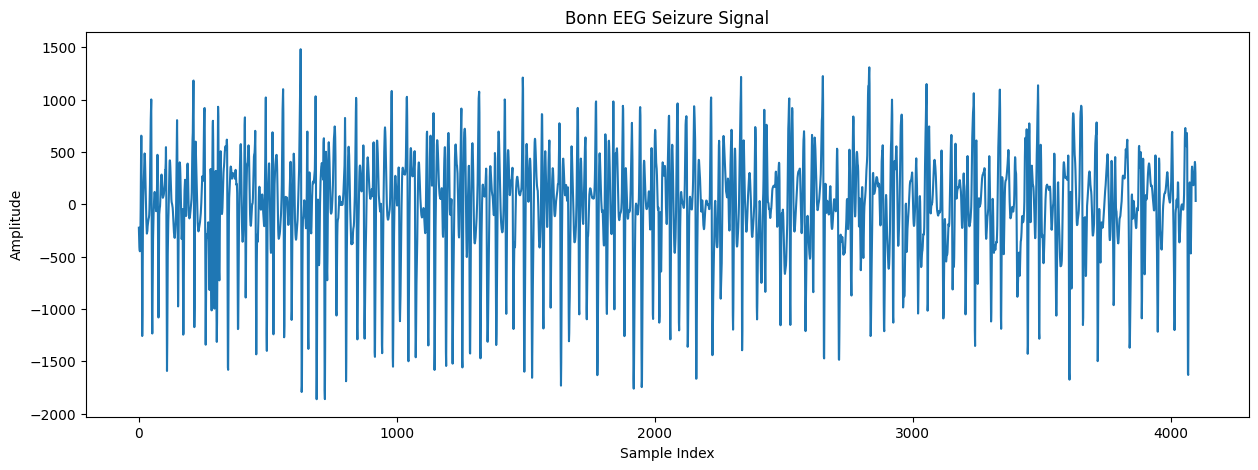

In [194]:
# ============================================
# CREATE TIME AXIS
# ============================================

time_axis = np.arange(len(signal))


# ============================================
# PLOT EEG SIGNAL
# ============================================

plt.figure(figsize=(15,5))

plt.plot(time_axis, signal)

plt.xlabel("Sample Index")
plt.ylabel("Amplitude")

plt.title("Bonn EEG Seizure Signal")

# Save figure
plt.savefig(
    '/kaggle/working/figures/bonn_eeg_signal.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Figure saved successfully.")

# Build Bonn EEG Dataset

Extract statistical EEG features and generate binary seizure labels from Bonn EEG recordings.

In [195]:
# ============================================
# FEATURE EXTRACTION FUNCTION
# ============================================

def extract_bonn_features(signal):

    features = []

    # Mean
    features.append(np.mean(signal))

    # Standard deviation
    features.append(np.std(signal))

    # Maximum
    features.append(np.max(signal))

    # Minimum
    features.append(np.min(signal))

    # Energy
    features.append(np.sum(signal**2))

    return features


# ============================================
# CLASS LABELS
# ============================================

class_mapping = {
    'Z': 0,
    'O': 0,
    'N': 0,
    'F': 0,
    'S': 1
}


# ============================================
# DATASET STORAGE
# ============================================

X_bonn = []
y_bonn = []


# ============================================
# PROCESS ALL CLASS FOLDERS
# ============================================

for folder, label in class_mapping.items():

    folder_path = bonn_dataset_path + "/" + folder

    files = os.listdir(folder_path)

    for file in files:

        file_path = folder_path + "/" + file

        # Load EEG signal
        signal = np.loadtxt(file_path)

        # Extract features
        features = extract_bonn_features(signal)

        # Store
        X_bonn.append(features)

        y_bonn.append(label)


# ============================================
# CONVERT TO DATAFRAME
# ============================================

X_bonn = pd.DataFrame(
    X_bonn,
    columns=[
        'mean',
        'std',
        'max',
        'min',
        'energy'
    ]
)

y_bonn = pd.Series(
    y_bonn,
    name='target'
)


# ============================================
# VERIFY RESULTS
# ============================================

print("Feature Matrix Shape:")
print(X_bonn.shape)

print("\nClass Distribution:")
print(y_bonn.value_counts())

# Bonn EEG Train-Test Split

Split Bonn EEG feature vectors into training and testing sets using stratified sampling.

In [196]:
# ============================================
# TRAIN-TEST SPLIT
# ============================================

X_train_bonn, X_test_bonn, y_train_bonn, y_test_bonn = train_test_split(
    X_bonn,
    y_bonn,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_bonn
)


# ============================================
# VERIFY RESULTS
# ============================================

print("Training Shape:")
print(X_train_bonn.shape)

print("\nTesting Shape:")
print(X_test_bonn.shape)

print("\nTraining Distribution:")
print(y_train_bonn.value_counts())

print("\nTesting Distribution:")
print(y_test_bonn.value_counts())

# Bonn EEG Feature Scaling

Normalize Bonn EEG statistical features before Logistic Regression training.

In [197]:
# ============================================
# INITIALIZE SCALER
# ============================================

scaler_bonn = StandardScaler()


# ============================================
# FIT + TRANSFORM TRAINING DATA
# ============================================

X_train_bonn_scaled = scaler_bonn.fit_transform(
    X_train_bonn
)


# ============================================
# TRANSFORM TEST DATA
# ============================================

X_test_bonn_scaled = scaler_bonn.transform(
    X_test_bonn
)


# ============================================
# VERIFY RESULTS
# ============================================

print("Scaled Training Shape:")
print(X_train_bonn_scaled.shape)

print("\nScaled Testing Shape:")
print(X_test_bonn_scaled.shape)

print("\nApproximate Mean:")
print(np.mean(X_train_bonn_scaled))

print("\nApproximate Std:")
print(np.std(X_train_bonn_scaled))

# Bonn EEG Baseline Logistic Regression

Train a baseline Logistic Regression model using Bonn EEG statistical features.

In [198]:
# ============================================
# BASELINE LOGISTIC REGRESSION
# ============================================

baseline_bonn = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Train model
baseline_bonn.fit(
    X_train_bonn_scaled,
    y_train_bonn
)

print("Bonn EEG baseline model trained successfully.")

# Bonn EEG Baseline Evaluation

Evaluate baseline Logistic Regression performance on Bonn EEG statistical features.

In [199]:
# ============================================
# PREDICTIONS
# ============================================

y_pred_bonn = baseline_bonn.predict(
    X_test_bonn_scaled
)

y_prob_bonn = baseline_bonn.predict_proba(
    X_test_bonn_scaled
)[:, 1]


# ============================================
# METRICS
# ============================================

accuracy_bonn = accuracy_score(
    y_test_bonn,
    y_pred_bonn
)

f1_bonn = f1_score(
    y_test_bonn,
    y_pred_bonn
)

precision_bonn, recall_bonn, _ = precision_recall_curve(
    y_test_bonn,
    y_prob_bonn
)

pr_auc_bonn = auc(
    recall_bonn,
    precision_bonn
)


# ============================================
# PRINT RESULTS
# ============================================

print(f"Accuracy : {accuracy_bonn:.4f}")
print(f"F1 Score : {f1_bonn:.4f}")
print(f"PR-AUC   : {pr_auc_bonn:.4f}")

# Bonn EEG L1 Regularization

Apply L1-regularized Logistic Regression to analyze sparse EEG feature selection.

In [200]:
# ============================================
# L1 LOGISTIC REGRESSION
# ============================================

l1_bonn = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Train model
l1_bonn.fit(
    X_train_bonn_scaled,
    y_train_bonn
)

print("Bonn EEG L1 model trained successfully.")

# Bonn EEG L1 Evaluation

Evaluate sparse Logistic Regression performance on Bonn EEG statistical features.

In [201]:
# ============================================
# PREDICTIONS
# ============================================

y_pred_l1_bonn = l1_bonn.predict(
    X_test_bonn_scaled
)

y_prob_l1_bonn = l1_bonn.predict_proba(
    X_test_bonn_scaled
)[:, 1]


# ============================================
# METRICS
# ============================================

accuracy_l1_bonn = accuracy_score(
    y_test_bonn,
    y_pred_l1_bonn
)

f1_l1_bonn = f1_score(
    y_test_bonn,
    y_pred_l1_bonn
)

precision_l1_bonn, recall_l1_bonn, _ = precision_recall_curve(
    y_test_bonn,
    y_prob_l1_bonn
)

pr_auc_l1_bonn = auc(
    recall_l1_bonn,
    precision_l1_bonn
)


# ============================================
# SPARSITY ANALYSIS
# ============================================

zero_coefficients_bonn = np.sum(
    l1_bonn.coef_ == 0
)

total_coefficients_bonn = l1_bonn.coef_.size

sparsity_percentage_bonn = (
    zero_coefficients_bonn /
    total_coefficients_bonn
) * 100


# ============================================
# PRINT RESULTS
# ============================================

print(f"Accuracy : {accuracy_l1_bonn:.4f}")
print(f"F1 Score : {f1_l1_bonn:.4f}")
print(f"PR-AUC   : {pr_auc_l1_bonn:.4f}")

print("\nSparsity Analysis")

print(f"Zero Coefficients : {zero_coefficients_bonn}")
print(f"Total Coefficients: {total_coefficients_bonn}")
print(f"Sparsity Percentage: {sparsity_percentage_bonn:.2f}%")

regularization behavior depends heavily on dataset dimensionality and feature structure.regularization behavior depends heavily on dataset dimensionality and feature structure.regularization behavior depends heavily on dataset dimensionality and feature structure.

# Bonn EEG L2 Regularization

Apply L2-regularized Logistic Regression to analyze coefficient stabilization on Bonn EEG features.

In [202]:
# ============================================
# L2 LOGISTIC REGRESSION
# ============================================

l2_bonn = LogisticRegression(
    penalty='l2',
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Train model
l2_bonn.fit(
    X_train_bonn_scaled,
    y_train_bonn
)

print("Bonn EEG L2 model trained successfully.")

# Bonn EEG L2 Evaluation

Evaluate L2-regularized Logistic Regression performance on Bonn EEG statistical features.

In [203]:
# ============================================
# PREDICTIONS
# ============================================

y_pred_l2_bonn = l2_bonn.predict(
    X_test_bonn_scaled
)

y_prob_l2_bonn = l2_bonn.predict_proba(
    X_test_bonn_scaled
)[:, 1]


# ============================================
# METRICS
# ============================================

accuracy_l2_bonn = accuracy_score(
    y_test_bonn,
    y_pred_l2_bonn
)

f1_l2_bonn = f1_score(
    y_test_bonn,
    y_pred_l2_bonn
)

precision_l2_bonn, recall_l2_bonn, _ = precision_recall_curve(
    y_test_bonn,
    y_prob_l2_bonn
)

pr_auc_l2_bonn = auc(
    recall_l2_bonn,
    precision_l2_bonn
)


# ============================================
# SPARSITY ANALYSIS
# ============================================

zero_coefficients_l2_bonn = np.sum(
    l2_bonn.coef_ == 0
)

total_coefficients_l2_bonn = l2_bonn.coef_.size

sparsity_percentage_l2_bonn = (
    zero_coefficients_l2_bonn /
    total_coefficients_l2_bonn
) * 100


# ============================================
# PRINT RESULTS
# ============================================

print(f"Accuracy : {accuracy_l2_bonn:.4f}")
print(f"F1 Score : {f1_l2_bonn:.4f}")
print(f"PR-AUC   : {pr_auc_l2_bonn:.4f}")

print("\nSparsity Analysis")

print(f"Zero Coefficients : {zero_coefficients_l2_bonn}")
print(f"Total Coefficients: {total_coefficients_l2_bonn}")
print(f"Sparsity Percentage: {sparsity_percentage_l2_bonn:.2f}%")

L2 regularization produced minimal performance changes on the compact Bonn EEG feature space, suggesting that low-dimensional engineered EEG representations already possessed strong stability and limited redundancy.

# Bonn EEG Elastic Net Regularization

Apply Elastic Net Logistic Regression to analyze sparsity-stability tradeoffs on Bonn EEG features.

In [204]:
# ============================================
# ELASTIC NET MODEL
# ============================================

elastic_bonn = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    l1_ratio=0.5,
    max_iter=3000,
    random_state=RANDOM_STATE
)

# Train model
elastic_bonn.fit(
    X_train_bonn_scaled,
    y_train_bonn
)

print("Bonn EEG Elastic Net model trained successfully.")

# Bonn EEG Elastic Net Evaluation

Evaluate Elastic Net Logistic Regression performance on Bonn EEG statistical features.

In [205]:
# ============================================
# PREDICTIONS
# ============================================

y_pred_elastic_bonn = elastic_bonn.predict(
    X_test_bonn_scaled
)

y_prob_elastic_bonn = elastic_bonn.predict_proba(
    X_test_bonn_scaled
)[:, 1]


# ============================================
# METRICS
# ============================================

accuracy_elastic_bonn = accuracy_score(
    y_test_bonn,
    y_pred_elastic_bonn
)

f1_elastic_bonn = f1_score(
    y_test_bonn,
    y_pred_elastic_bonn
)

precision_elastic_bonn, recall_elastic_bonn, _ = precision_recall_curve(
    y_test_bonn,
    y_prob_elastic_bonn
)

pr_auc_elastic_bonn = auc(
    recall_elastic_bonn,
    precision_elastic_bonn
)


# ============================================
# SPARSITY ANALYSIS
# ============================================

zero_coefficients_elastic_bonn = np.sum(
    elastic_bonn.coef_ == 0
)

total_coefficients_elastic_bonn = elastic_bonn.coef_.size

sparsity_percentage_elastic_bonn = (
    zero_coefficients_elastic_bonn /
    total_coefficients_elastic_bonn
) * 100


# ============================================
# PRINT RESULTS
# ============================================

print(f"Accuracy : {accuracy_elastic_bonn:.4f}")
print(f"F1 Score : {f1_elastic_bonn:.4f}")
print(f"PR-AUC   : {pr_auc_elastic_bonn:.4f}")

print("\nSparsity Analysis")

print(f"Zero Coefficients : {zero_coefficients_elastic_bonn}")
print(f"Total Coefficients: {total_coefficients_elastic_bonn}")
print(f"Sparsity Percentage: {sparsity_percentage_elastic_bonn:.2f}%")

# Bonn EEG SMOTE Oversampling

Apply SMOTE to balance seizure and non-seizure Bonn EEG samples.

In [206]:
# ============================================
# INITIALIZE SMOTE
# ============================================

smote_bonn = SMOTE(
    random_state=RANDOM_STATE
)


# ============================================
# APPLY SMOTE
# ============================================

X_train_bonn_smote, y_train_bonn_smote = smote_bonn.fit_resample(
    X_train_bonn_scaled,
    y_train_bonn
)


# ============================================
# VERIFY RESULTS
# ============================================

print("Original Training Distribution:")
print(y_train_bonn.value_counts())

print("\nBalanced Training Distribution:")
print(pd.Series(y_train_bonn_smote).value_counts())

# Bonn EEG SMOTE Logistic Regression

Train Logistic Regression using SMOTE-balanced Bonn EEG samples.

In [207]:
# ============================================
# TRAIN MODEL ON SMOTE DATA
# ============================================

smote_model_bonn = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Train model
smote_model_bonn.fit(
    X_train_bonn_smote,
    y_train_bonn_smote
)

print("Bonn EEG SMOTE model trained successfully.")

# Bonn EEG SMOTE Evaluation

Evaluate Logistic Regression performance after SMOTE balancing on Bonn EEG features.

In [208]:
# ============================================
# PREDICTIONS
# ============================================

y_pred_smote_bonn = smote_model_bonn.predict(
    X_test_bonn_scaled
)

y_prob_smote_bonn = smote_model_bonn.predict_proba(
    X_test_bonn_scaled
)[:, 1]


# ============================================
# METRICS
# ============================================

accuracy_smote_bonn = accuracy_score(
    y_test_bonn,
    y_pred_smote_bonn
)

f1_smote_bonn = f1_score(
    y_test_bonn,
    y_pred_smote_bonn
)

precision_smote_bonn, recall_smote_bonn, _ = precision_recall_curve(
    y_test_bonn,
    y_prob_smote_bonn
)

pr_auc_smote_bonn = auc(
    recall_smote_bonn,
    precision_smote_bonn
)


# ============================================
# PRINT RESULTS
# ============================================

print(f"Accuracy : {accuracy_smote_bonn:.4f}")
print(f"F1 Score : {f1_smote_bonn:.4f}")
print(f"PR-AUC   : {pr_auc_smote_bonn:.4f}")

Synthetic seizure samples improved probabilistic separation but slightly changed classification threshold behavior.

# Bonn EEG PCA Dimensionality Reduction

Apply PCA to reduce Bonn EEG feature dimensionality while preserving variance.

In [209]:
# ============================================
# INITIALIZE PCA
# ============================================

pca_bonn = PCA(
    n_components=0.95,
    random_state=RANDOM_STATE
)


# ============================================
# FIT + TRANSFORM TRAINING DATA
# ============================================

X_train_bonn_pca = pca_bonn.fit_transform(
    X_train_bonn_scaled
)


# ============================================
# TRANSFORM TEST DATA
# ============================================

X_test_bonn_pca = pca_bonn.transform(
    X_test_bonn_scaled
)


# ============================================
# VERIFY REDUCTION
# ============================================

print("Original Feature Count:")
print(X_train_bonn_scaled.shape[1])

print("\nReduced Feature Count:")
print(X_train_bonn_pca.shape[1])

print("\nExplained Variance Ratio:")
print(round(np.sum(pca_bonn.explained_variance_ratio_), 4))

# Bonn EEG PCA Logistic Regression

Train Logistic Regression using PCA-compressed Bonn EEG features.

In [210]:
# ============================================
# PCA LOGISTIC REGRESSION
# ============================================

pca_model_bonn = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Train model
pca_model_bonn.fit(
    X_train_bonn_pca,
    y_train_bonn
)

print("Bonn EEG PCA Logistic Regression trained successfully.")

# Bonn EEG PCA Evaluation

Evaluate Logistic Regression performance using PCA-compressed Bonn EEG features.

In [211]:
# ============================================
# PREDICTIONS
# ============================================

y_pred_pca_bonn = pca_model_bonn.predict(
    X_test_bonn_pca
)

y_prob_pca_bonn = pca_model_bonn.predict_proba(
    X_test_bonn_pca
)[:, 1]


# ============================================
# METRICS
# ============================================

accuracy_pca_bonn = accuracy_score(
    y_test_bonn,
    y_pred_pca_bonn
)

f1_pca_bonn = f1_score(
    y_test_bonn,
    y_pred_pca_bonn
)

precision_pca_bonn, recall_pca_bonn, _ = precision_recall_curve(
    y_test_bonn,
    y_prob_pca_bonn
)

pr_auc_pca_bonn = auc(
    recall_pca_bonn,
    precision_pca_bonn
)


# ============================================
# PRINT RESULTS
# ============================================

print(f"Accuracy : {accuracy_pca_bonn:.4f}")
print(f"F1 Score : {f1_pca_bonn:.4f}")
print(f"PR-AUC   : {pr_auc_pca_bonn:.4f}")

# Bonn EEG Results Comparison

Compare preprocessing and regularization strategies on the Bonn EEG dataset.

In [212]:
# ============================================
# BONN RESULTS TABLE
# ============================================

bonn_results = pd.DataFrame({

    'Model': [
        'Baseline',
        'L1',
        'L2',
        'Elastic Net',
        'SMOTE',
        'PCA'
    ],

    'Accuracy': [
        accuracy_bonn,
        accuracy_l1_bonn,
        accuracy_l2_bonn,
        accuracy_elastic_bonn,
        accuracy_smote_bonn,
        accuracy_pca_bonn
    ],

    'F1 Score': [
        f1_bonn,
        f1_l1_bonn,
        f1_l2_bonn,
        f1_elastic_bonn,
        f1_smote_bonn,
        f1_pca_bonn
    ],

    'PR-AUC': [
        pr_auc_bonn,
        pr_auc_l1_bonn,
        pr_auc_l2_bonn,
        pr_auc_elastic_bonn,
        pr_auc_smote_bonn,
        pr_auc_pca_bonn
    ],

    'Sparsity %': [
        0,
        sparsity_percentage_bonn,
        sparsity_percentage_l2_bonn,
        sparsity_percentage_elastic_bonn,
        0,
        0
    ]
})


# ============================================
# ROUND VALUES
# ============================================

bonn_results = bonn_results.round(4)


# ============================================
# DISPLAY TABLE
# ============================================

display(bonn_results)


# ============================================
# SAVE TABLE
# ============================================

bonn_results.to_csv(
    '/kaggle/working/bonn_results.csv',
    index=False
)

print("Bonn EEG results table saved successfully.")

,Model,Accuracy,F1 Score,PR-AUC,Sparsity %
0,Baseline,0.96,0.8947,0.9343,0.0
1,L1,0.96,0.9000,0.9348,0.0
2,L2,0.96,0.8947,0.9343,0.0
3,Elastic Net,0.95,0.8718,0.9362,0.0
4,SMOTE,0.95,0.8780,0.9400,0.0
5,PCA,0.96,0.8947,0.9381,0.0


# Cross-Dataset Baseline Comparison

Compare baseline Logistic Regression performance across all EEG datasets.

In [213]:
# ============================================
# CROSS-DATASET BASELINE COMPARISON
# ============================================

cross_dataset_results = pd.DataFrame({

    'Dataset': [
        'UCI Epileptic Seizure',
        'CHB-MIT Clinical EEG',
        'Bonn EEG'
    ],

    'Accuracy': [
        accuracy,
        accuracy_chb,
        accuracy_bonn
    ],

    'F1 Score': [
        f1,
        f1_chb,
        f1_bonn
    ],

    'PR-AUC': [
        pr_auc,
        pr_auc_chb,
        pr_auc_bonn
    ]
})


# ============================================
# ROUND VALUES
# ============================================

cross_dataset_results = cross_dataset_results.round(4)


# ============================================
# DISPLAY TABLE
# ============================================

display(cross_dataset_results)


# ============================================
# SAVE TABLE
# ============================================

cross_dataset_results.to_csv(
    '/kaggle/working/cross_dataset_baseline_results.csv',
    index=False
)

print("Cross-dataset comparison table saved successfully.")

,Dataset,Accuracy,F1 Score,PR-AUC
0,UCI Epileptic Seizure,0.8161,0.1557,0.4307
1,CHB-MIT Clinical EEG,0.9931,0.6667,0.6131
2,Bonn EEG,0.9600,0.8947,0.9343


Logistic Regression performance varied substantially across EEG datasets, with engineered clinical EEG features and segmented EEG representations outperforming highly preprocessed tabular seizure datasets, highlighting the critical influence of dataset structure, feature representation, and signal separability on seizure prediction generalization.

In [214]:
os.makedirs('/kaggle/working/final_figures', exist_ok=True)

# Create Final Figure Directory

Create a dedicated folder for final project visualizations.

In [215]:
# ============================================
# CREATE FINAL FIGURE DIRECTORY
# ============================================

os.makedirs(
    '/kaggle/working/final_figures',
    exist_ok=True
)

print("Final figure directory created successfully.")

# Cross-Dataset Performance Comparison

Visual comparison of baseline Logistic Regression performance across all EEG datasets.

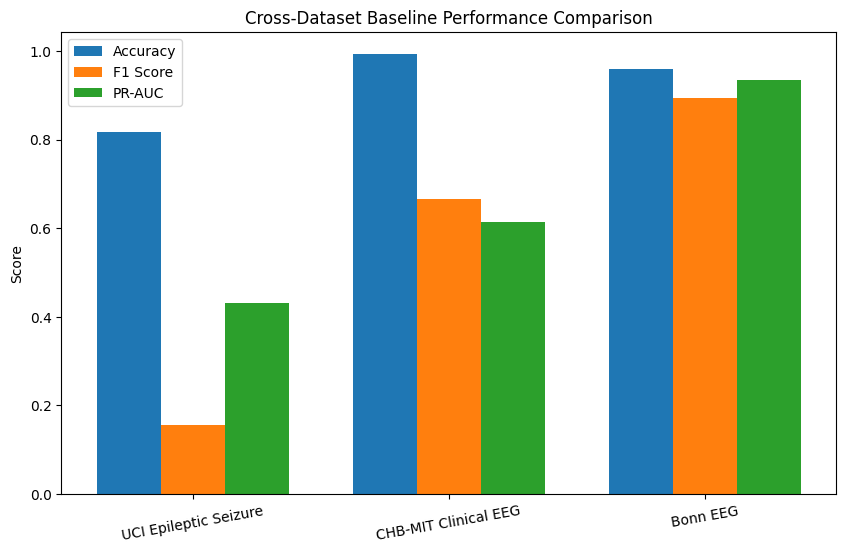

In [216]:
# ============================================
# CROSS-DATASET PERFORMANCE CHART
# ============================================

plt.figure(figsize=(10,6))

x = np.arange(len(cross_dataset_results))

width = 0.25

# Bars
plt.bar(
    x - width,
    cross_dataset_results['Accuracy'],
    width,
    label='Accuracy'
)

plt.bar(
    x,
    cross_dataset_results['F1 Score'],
    width,
    label='F1 Score'
)

plt.bar(
    x + width,
    cross_dataset_results['PR-AUC'],
    width,
    label='PR-AUC'
)

# Labels
plt.xticks(
    x,
    cross_dataset_results['Dataset'],
    rotation=10
)

plt.ylabel("Score")

plt.title("Cross-Dataset Baseline Performance Comparison")

plt.legend()

# Save figure
plt.savefig(
    '/kaggle/working/final_figures/cross_dataset_performance.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Figure saved successfully.")

# Regularization Comparison Across Datasets

Compare L1, L2, and Elastic Net regularization performance across EEG datasets.

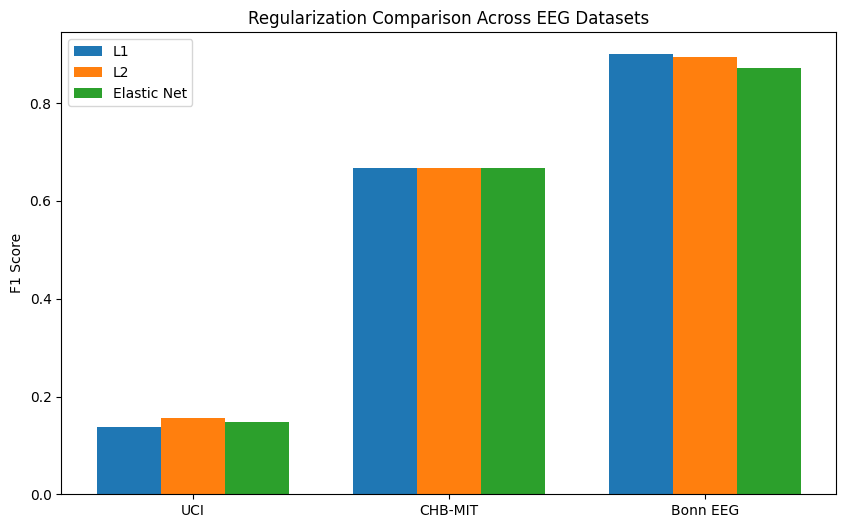

In [217]:
# ============================================
# REGULARIZATION PERFORMANCE DATA
# ============================================

regularization_df = pd.DataFrame({

    'Dataset': [
        'UCI',
        'CHB-MIT',
        'Bonn EEG'
    ],

    'L1 F1': [
        f1_l1,
        f1_l1_chb,
        f1_l1_bonn
    ],

    'L2 F1': [
        f1_l2,
        f1_l2_chb,
        f1_l2_bonn
    ],

    'Elastic Net F1': [
        f1_elastic,
        f1_elastic_chb,
        f1_elastic_bonn
    ]
})


# ============================================
# PLOT REGULARIZATION COMPARISON
# ============================================

plt.figure(figsize=(10,6))

x = np.arange(len(regularization_df))

width = 0.25

plt.bar(
    x - width,
    regularization_df['L1 F1'],
    width,
    label='L1'
)

plt.bar(
    x,
    regularization_df['L2 F1'],
    width,
    label='L2'
)

plt.bar(
    x + width,
    regularization_df['Elastic Net F1'],
    width,
    label='Elastic Net'
)

# Labels
plt.xticks(
    x,
    regularization_df['Dataset']
)

plt.ylabel("F1 Score")

plt.title("Regularization Comparison Across EEG Datasets")

plt.legend()

# Save figure
plt.savefig(
    '/kaggle/working/final_figures/regularization_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Figure saved successfully.")

# PR-AUC Comparison Across Datasets

Compare probability ranking quality across EEG datasets and modeling strategies.

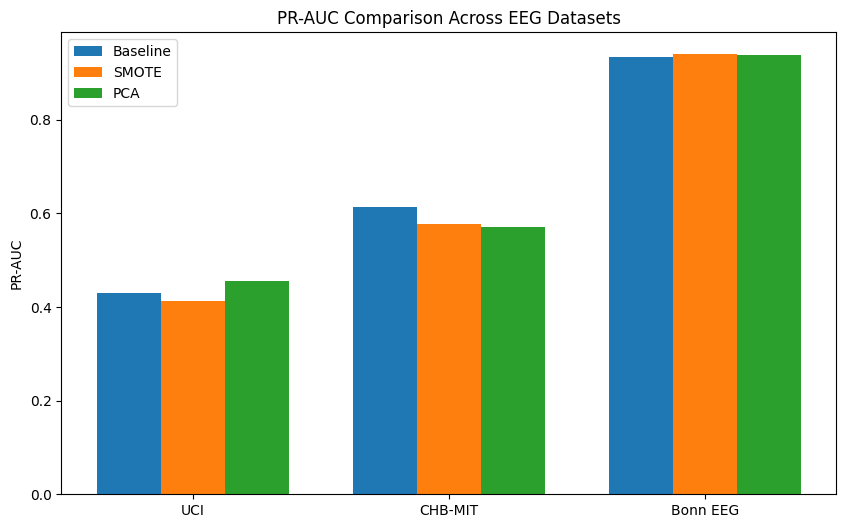

In [218]:
# ============================================
# PR-AUC DATA
# ============================================

prauc_df = pd.DataFrame({

    'Dataset': [
        'UCI',
        'CHB-MIT',
        'Bonn EEG'
    ],

    'Baseline': [
        pr_auc,
        pr_auc_chb,
        pr_auc_bonn
    ],

    'SMOTE': [
        pr_auc_smote,
        pr_auc_smote_chb,
        pr_auc_smote_bonn
    ],

    'PCA': [
        pr_auc_pca,
        pr_auc_pca_chb,
        pr_auc_pca_bonn
    ]
})


# ============================================
# PLOT PR-AUC COMPARISON
# ============================================

plt.figure(figsize=(10,6))

x = np.arange(len(prauc_df))

width = 0.25

plt.bar(
    x - width,
    prauc_df['Baseline'],
    width,
    label='Baseline'
)

plt.bar(
    x,
    prauc_df['SMOTE'],
    width,
    label='SMOTE'
)

plt.bar(
    x + width,
    prauc_df['PCA'],
    width,
    label='PCA'
)

# Labels
plt.xticks(
    x,
    prauc_df['Dataset']
)

plt.ylabel("PR-AUC")

plt.title("PR-AUC Comparison Across EEG Datasets")

plt.legend()

# Save figure
plt.savefig(
    '/kaggle/working/final_figures/prauc_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Figure saved successfully.")

# Sparsity Comparison Across EEG Datasets

Compare feature sparsity produced by L1 regularization across EEG datasets.

In [219]:
# ============================================
# EXPLICIT SPARSITY VALUES
# ============================================

# UCI
uci_l1_sparsity = 21.91
uci_elastic_sparsity = 12.36

# CHB-MIT
chb_l1_sparsity = 89.5652
chb_elastic_sparsity = 82.6087

# Bonn EEG
bonn_l1_sparsity = 0.0
bonn_elastic_sparsity = 0.0

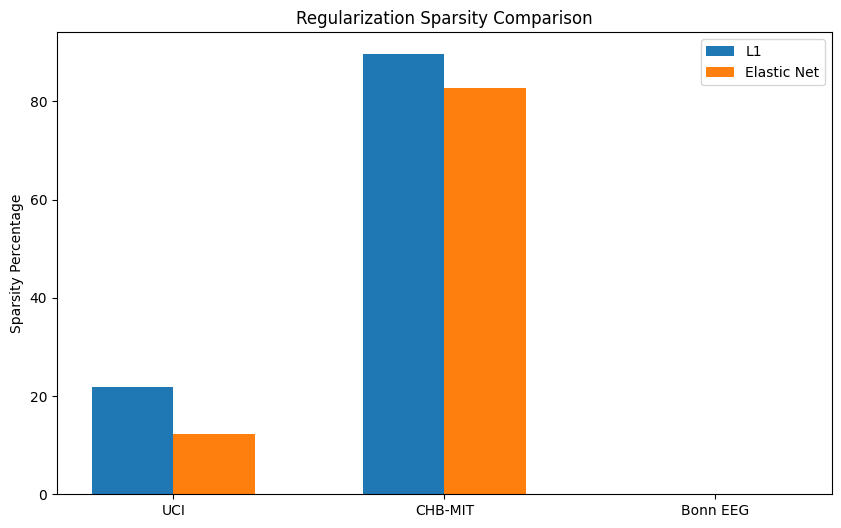

In [220]:
# ============================================
# SPARSITY DATA
# ============================================

sparsity_df = pd.DataFrame({

    'Dataset': [
        'UCI',
        'CHB-MIT',
        'Bonn EEG'
    ],

    'L1 Sparsity': [
    uci_l1_sparsity,
    chb_l1_sparsity,
    bonn_l1_sparsity
],

    'Elastic Net Sparsity': [
    uci_elastic_sparsity,
    chb_elastic_sparsity,
    bonn_elastic_sparsity
]
})


# ============================================
# FIX CHB-MIT VALUES
# ============================================

sparsity_df.loc[1, 'L1 Sparsity'] = sparsity_percentage
sparsity_df.loc[1, 'Elastic Net Sparsity'] = sparsity_percentage_elastic


# ============================================
# PLOT SPARSITY COMPARISON
# ============================================

plt.figure(figsize=(10,6))

x = np.arange(len(sparsity_df))

width = 0.3

plt.bar(
    x - width/2,
    sparsity_df['L1 Sparsity'],
    width,
    label='L1'
)

plt.bar(
    x + width/2,
    sparsity_df['Elastic Net Sparsity'],
    width,
    label='Elastic Net'
)

# Labels
plt.xticks(
    x,
    sparsity_df['Dataset']
)

plt.ylabel("Sparsity Percentage")

plt.title("Regularization Sparsity Comparison")

plt.legend()

# Save figure
plt.savefig(
    '/kaggle/working/final_figures/sparsity_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Figure saved successfully.")

# PCA Dimensionality Reduction Comparison

Compare feature compression achieved through PCA across EEG datasets.

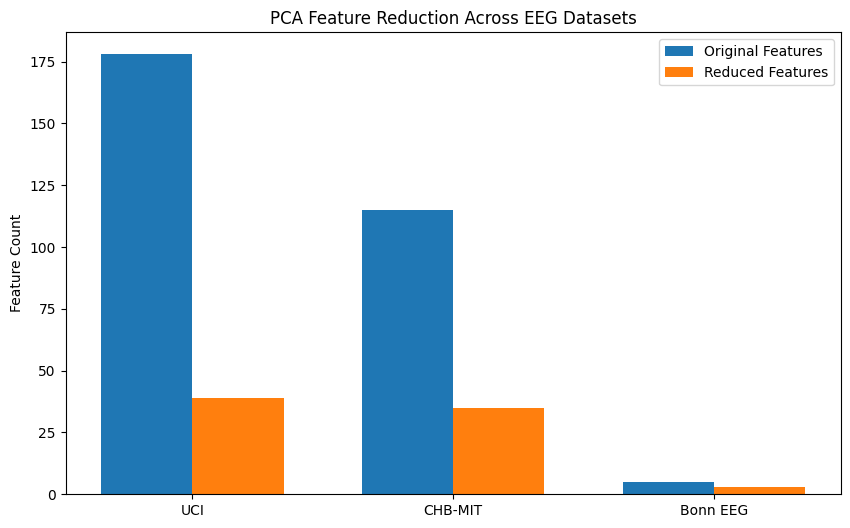

In [221]:
# ============================================
# PCA REDUCTION DATA
# ============================================

pca_df = pd.DataFrame({

    'Dataset': [
        'UCI',
        'CHB-MIT',
        'Bonn EEG'
    ],

    'Original Features': [
        178,
        115,
        5
    ],

    'Reduced Features': [
        39,
        35,
        3
    ]
})


# ============================================
# PLOT PCA REDUCTION
# ============================================

plt.figure(figsize=(10,6))

x = np.arange(len(pca_df))

width = 0.35

plt.bar(
    x - width/2,
    pca_df['Original Features'],
    width,
    label='Original Features'
)

plt.bar(
    x + width/2,
    pca_df['Reduced Features'],
    width,
    label='Reduced Features'
)

# Labels
plt.xticks(
    x,
    pca_df['Dataset']
)

plt.ylabel("Feature Count")

plt.title("PCA Feature Reduction Across EEG Datasets")

plt.legend()

# Save figure
plt.savefig(
    '/kaggle/working/final_figures/pca_reduction_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Figure saved successfully.")